In [6]:
from bs4 import BeautifulSoup

# ---------------------------------------
# YOUR HTML ROW (already included below)
# ---------------------------------------
html = """
<tr style="background:#e2e0df !important">
    <td>
        <div style="font-weight: bold">
            1010 EAST 178TH STREET  - Entire Development
        </div>
        <span style="display: block;">
            1010 EAST 178TH STREET<br>
            BRONX, NY 10460<br>
        </span>
        <span style="display: none;">Sectional</span>
    </td>

    <td>
        <span style="padding-bottom: 5px; display: none;">
            <img src="images/heat-01.svg" alt="Heat">Heat<br>
        </span>
        <span style="padding-bottom: 5px; display: block;">
            <img src="images/hotwater-01.svg" alt="Hot Water">Hot Water<br>
        </span>
        <span style="padding-bottom: 5px; display: none;">
            <img src="images/water-01.svg" alt="Water">Water
        </span>
    </td>

    <td>
        <span style="padding-bottom: 5px; display: none;">
            <img src="images/unplanned-01.svg" alt="Unplanned"><br>Unplanned
        </span>
        <span style="padding-bottom: 5px; display: block;">
            <img src="images/unplanned-01.svg" alt="Unplanned"><br>Unplanned
        </span>
    </td>

    <td>
        10/29/24<br>
        06:45 AM
    </td>

    <td>
        10/29/24 09:57 PM
    </td>

    <td>
        <table class="nested" style="display: block;">
            <tr>
                <th>Buildings</th>
                <th>Units</th>
                <th>Residents</th>
            </tr>
            <tr>
                <td>1</td>
                <td>220</td>
                <td>0</td>
            </tr>
        </table>
    </td>
</tr>
"""

soup = BeautifulSoup(html, "html.parser")

# ---- 1. Development Name ----
development_name = soup.find("div").get_text(strip=True)

# ---- 2. Address ----
address_block = soup.find_all("span")[0]
address = address_block.get_text(separator=" ", strip=True)

# ---- 3. Utility Type (Heat / Hot Water / Water etc.) ----
utility_spans = soup.find_all("td")[1].find_all("span")
utility_type = ""
for sp in utility_spans:
    if "display: block" in sp.get("style", ""):
        utility_type = sp.get_text(strip=True)
        break

# ---- 4. Status ----
status_spans = soup.find_all("td")[2].find_all("span")
status = ""
for sp in status_spans:
    if "display: block" in sp.get("style", ""):
        status = sp.get_text(strip=True)
        break

# ---- 5. Start Date + Time ----
start_td = soup.find_all("td")[3]
start_text = start_td.get_text(separator=" ", strip=True)
start_date, start_time = start_text.split(" ", 1)

# ---- 6. Estimated Restoration ----
estimated_restoration = soup.find_all("td")[4].get_text(strip=True)

# ---- 7. Buildings / Units / Residents ----
nested_row = soup.find("table", class_="nested").find_all("tr")[1].find_all("td")
buildings = nested_row[0].get_text(strip=True)
units = nested_row[1].get_text(strip=True)
residents = nested_row[2].get_text(strip=True)

# ---- Print results ----
print("Development:", development_name)
print("Address:", address)
print("Utility:", utility_type)
print("Status:", status)
print("Start Date:", start_date)
print("Start Time:", start_time)
print("Estimated Restoration:", estimated_restoration)
print("Buildings:", buildings)
print("Units:", units)
print("Residents:", residents)


Development: 1010 EAST 178TH STREET  - Entire Development
Address: 1010 EAST 178TH STREET BRONX, NY 10460
Utility: Hot Water
Status: Unplanned
Start Date: 10/29/24
Start Time: 06:45 AM
Estimated Restoration: 10/29/24 09:57 PM
Buildings: 1
Units: 220
Residents: 0


In [9]:
!pip install playwright
!playwright install --with-deps firefox


In [10]:
!playwright install firefox


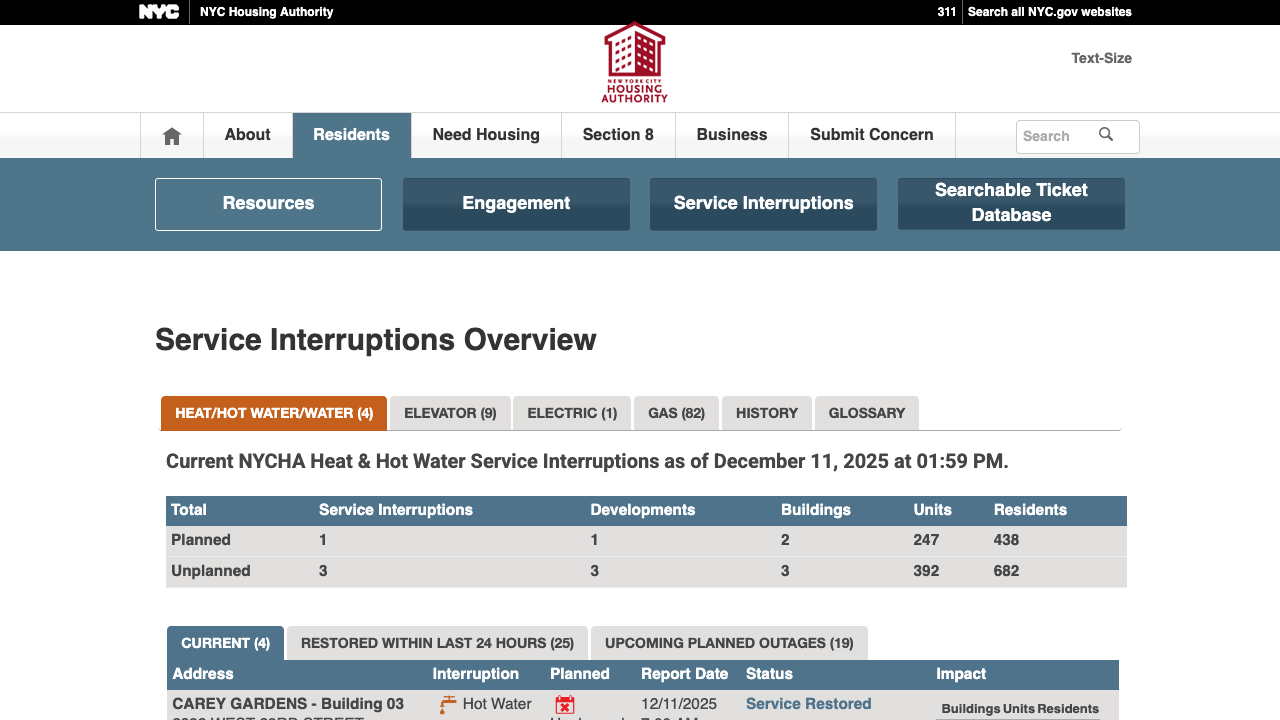

In [11]:
from playwright.async_api import async_playwright
import asyncio
from IPython.display import Image, display

async def load_page():
    async with async_playwright() as p:
        browser = await p.firefox.launch(headless=True)
        page = await browser.new_page()

        # Go to NYCHA Outages page
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", wait_until="networkidle")

        # Take a screenshot so we know it loaded
        await page.screenshot(path="nycha_page.png")

        await browser.close()

# Run the async function
await load_page()

# Display screenshot
display(Image(filename="nycha_page.png"))


In [12]:
from playwright.async_api import async_playwright
import asyncio
from IPython.display import Image, display

async def select_heat_only():
    async with async_playwright() as p:
        browser = await p.firefox.launch(headless=True)
        page = await browser.new_page()

        # Load page
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", wait_until="networkidle")

        # Select "Heat" from dropdown (value should match the website's option value)
        await page.select_option("#ctl00_PlaceHolderMain_ddlUtilityType", label="Heat")

        # Wait for table to reload
        await page.wait_for_load_state("networkidle")

        # Screenshot to confirm
        await page.screenshot(path="heat_selected.png")

        await browser.close()

# Run it
await select_heat_only()

display(Image(filename="heat_selected.png"))


TimeoutError: Page.select_option: Timeout 30000ms exceeded.
Call log:
  - waiting for locator("#ctl00_PlaceHolderMain_ddlUtilityType")


In [13]:
from playwright.async_api import async_playwright
import asyncio

async def find_select_ids():
    async with async_playwright() as p:
        browser = await p.firefox.launch(headless=True)
        page = await browser.new_page()

        await page.goto("https://my.nycha.info/Outages/Outages.aspx", wait_until="networkidle")

        # Get all <select> elements
        select_ids = await page.eval_on_selector_all(
            "select",
            "elements => elements.map(e => ({id: e.id, name: e.name}))"
        )

        print(select_ids)

        await browser.close()

await find_select_ids()


[{'id': 'ctl00_ContentPlaceHolder1_historicalOutagesList_drpBoroughs', 'name': 'ctl00$ContentPlaceHolder1$historicalOutagesList$drpBoroughs'}, {'id': 'ctl00_ContentPlaceHolder1_historicalOutagesList_drpDevelopments', 'name': 'ctl00$ContentPlaceHolder1$historicalOutagesList$drpDevelopments'}, {'id': 'ctl00_ContentPlaceHolder1_historicalOutagesList_drpBuildings', 'name': 'ctl00$ContentPlaceHolder1$historicalOutagesList$drpBuildings'}, {'id': 'ctl00_ContentPlaceHolder1_historicalOutagesList_drpAddressess', 'name': 'ctl00$ContentPlaceHolder1$historicalOutagesList$drpAddressess'}, {'id': 'ctl00_ContentPlaceHolder1_historicalOutagesList_drpOutageType', 'name': 'ctl00$ContentPlaceHolder1$historicalOutagesList$drpOutageType'}]


In [14]:
from playwright.async_api import async_playwright
import asyncio
from IPython.display import Image, display

async def select_heat_only():
    async with async_playwright() as p:
        browser = await p.firefox.launch(headless=True)
        page = await browser.new_page()

        await page.goto("https://my.nycha.info/Outages/Outages.aspx", wait_until="networkidle")

        # Select "Heat" from the correct dropdown
        await page.select_option(
            "#ctl00_ContentPlaceHolder1_historicalOutagesList_drpOutageType",
            label="Heat"
        )

        # Wait for table update
        await page.wait_for_load_state("networkidle")

        # Screenshot
        await page.screenshot(path="heat_selected.png")

        await browser.close()

await select_heat_only()
display(Image(filename="heat_selected.png"))


TimeoutError: Page.select_option: Timeout 30000ms exceeded.
Call log:
  - waiting for locator("#ctl00_ContentPlaceHolder1_historicalOutagesList_drpOutageType")
    - locator resolved to <select size="4" multiple="multiple" id="ctl00_ContentPlaceHolder1_historicalOutagesList_drpOutageType" name="ctl00$ContentPlaceHolder1$historicalOutagesList$drpOutageType">…</select>
  - attempting select option action
    2 × waiting for element to be visible and enabled
      - element is not visible
    - retrying select option action
    - waiting 20ms
    2 × waiting for element to be visible and enabled
      - element is not visible
    - retrying select option action
      - waiting 100ms
    58 × waiting for element to be visible and enabled
       - element is not visible
     - retrying select option action
       - waiting 500ms


In [15]:
from playwright.async_api import async_playwright
import asyncio
from IPython.display import Image, display

async def load_heat_and_hotwater():
    async with async_playwright() as p:
        browser = await p.firefox.launch(headless=True)
        page = await browser.new_page()

        # Step 1 — Load page
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", wait_until="networkidle")

        # Step 2 — Fill date range
        await page.fill("#fromdatepicker", "10/01/2024")
        await page.fill("#todatepicker", "05/31/2025")

        # Give the page a moment to process date input
        await page.wait_for_timeout(1000)

        # Step 3 — Select Heat + Hot Water
        await page.select_option(
            "#ctl00_ContentPlaceHolder1_historicalOutagesList_drpOutageType",
            ["NOHEAT", "NOHOTWATER"]
        )

        # Step 4 — Wait for results to load
        await page.wait_for_load_state("networkidle")

        # Step 5 — Screenshot for confirmation
        await page.screenshot(path="heat_hotwater_results.png")

        await browser.close()

# Run
await load_heat_and_hotwater()
display(Image(filename="heat_hotwater_results.png"))


TimeoutError: Page.fill: Timeout 30000ms exceeded.
Call log:
  - waiting for locator("#fromdatepicker")
    - locator resolved to <input type="text" id="fromdatepicker" class="hasDatepicker"/>
    - fill("10/01/2024")
  - attempting fill action
    2 × waiting for element to be visible, enabled and editable
      - element is not visible
    - retrying fill action
    - waiting 20ms
    2 × waiting for element to be visible, enabled and editable
      - element is not visible
    - retrying fill action
      - waiting 100ms
    58 × waiting for element to be visible, enabled and editable
       - element is not visible
     - retrying fill action
       - waiting 500ms


In [16]:
from playwright.async_api import async_playwright
import asyncio
from IPython.display import Image, display

async def test_date_fields():
    async with async_playwright() as p:
        browser = await p.firefox.launch(headless=True)
        page = await browser.new_page()

        await page.goto("https://my.nycha.info/Outages/Outages.aspx", wait_until="networkidle")

        # CLICK the date inputs first (this makes them visible)
        await page.click("#fromdatepicker")
        await page.fill("#fromdatepicker", "10/01/2024")

        await page.click("#todatepicker")
        await page.fill("#todatepicker", "05/31/2025")

        # Screenshot for confirmation
        await page.screenshot(path="date_filled.png")

        await browser.close()

# Run it
await test_date_fields()
display(Image(filename="date_filled.png"))


TimeoutError: Page.click: Timeout 30000ms exceeded.
Call log:
  - waiting for locator("#fromdatepicker")
    - locator resolved to <input type="text" id="fromdatepicker" class="hasDatepicker"/>
  - attempting click action
    2 × waiting for element to be visible, enabled and stable
      - element is not visible
    - retrying click action
    - waiting 20ms
    2 × waiting for element to be visible, enabled and stable
      - element is not visible
    - retrying click action
      - waiting 100ms
    56 × waiting for element to be visible, enabled and stable
       - element is not visible
     - retrying click action
       - waiting 500ms


In [17]:
from playwright.async_api import async_playwright
import asyncio

async def find_iframes():
    async with async_playwright() as p:
        browser = await p.firefox.launch(headless=True)
        page = await browser.new_page()

        await page.goto("https://my.nycha.info/Outages/Outages.aspx", wait_until="networkidle")

        frames = page.frames
        print("IFRAME COUNT:", len(frames))
        for f in frames:
            print("FRAME NAME:", f.name, "| FRAME URL:", f.url)

        await browser.close()

await find_iframes()


IFRAME COUNT: 3
FRAME NAME:  | FRAME URL: https://my.nycha.info/Outages/Outages.aspx
FRAME NAME: votingFrame | FRAME URL: about:blank
FRAME NAME:  | FRAME URL: https://my.nycha.info/Outages/Outages.aspx


In [18]:
id="fromdatepicker"


In [19]:
from playwright.async_api import async_playwright
import asyncio

async def inspect_frames():
    async with async_playwright() as p:
        browser = await p.firefox.launch(headless=True)
        page = await browser.new_page()
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", wait_until="networkidle")

        # Loop through frames
        for idx, frame in enumerate(page.frames):
            print("\n=== FRAME", idx, "URL:", frame.url, "===")
            try:
                # Try to get the outer HTML
                html = await frame.content()
                # Print only first 500 chars (to avoid overwhelming output)
                print(html[:500])
            except:
                print("Could not read frame content")

        await browser.close()

await inspect_frames()



=== FRAME 0 URL: https://my.nycha.info/Outages/Outages.aspx ===
<!DOCTYPE html><html class=" js no-touch csstransforms csstransforms3d csstransitions svg" style="height: 100%;"><!--<![endif]--><head id="ctl00_Head1"><meta http-equiv="Content-Type" content="text/html; charset=UTF-8"><title>
	Elevator, Gas, Heat and Hot Water Outages
</title><link href="https://www1.nyc.gov/iwov-resources/fixed-layout/3-Row Simple.css" type="text/css" rel="stylesheet"><meta name="keywords"><meta name="description"><meta name="vpath"><meta name="page-locale-name"><meta charset=

=== FRAME 1 URL: about:blank ===
<html><head></head><body></body></html>

=== FRAME 2 URL: https://my.nycha.info/Outages/Outages.aspx ===
<html><head><meta http-equiv="Content-Type" content="text/html; charset=UTF8"><link rel="stylesheet" type="text/css" href="https://www.gstatic.com/_/translate_http/_/ss/k=translate_http.tr.Qrtd5lGlzn4.L.F4.O/am=AAQD/d=0/rs=AN8SPfo9mDPo5pOm0HC4yPcwcdDdHSiNXw/m=el_main_css"></head><body scroll="n

In [20]:
from playwright.async_api import async_playwright
import asyncio
from IPython.display import Image, display

async def test_scroll_and_fill_dates():
    async with async_playwright() as p:
        browser = await p.firefox.launch(headless=True)
        page = await browser.new_page()

        await page.goto("https://my.nycha.info/Outages/Outages.aspx", wait_until="networkidle")

        # Scroll down to bring date fields into view
        await page.evaluate("window.scrollBy(0, 400)")  # adjust as needed

        # Click inside the FROM date field
        await page.click("#fromdatepicker", force=True)
        await page.fill("#fromdatepicker", "10/01/2024")

        # Click inside the TO date field
        await page.click("#todatepicker", force=True)
        await page.fill("#todatepicker", "05/31/2025")

        # Screenshot to confirm
        await page.screenshot(path="date_fields_scrolled.png")

        await browser.close()

# Run it
await test_scroll_and_fill_dates()
display(Image(filename="date_fields_scrolled.png"))


Error: Page.click: Element is not visible
Call log:
  - waiting for locator("#fromdatepicker")
    - locator resolved to <input type="text" id="fromdatepicker" class="hasDatepicker"/>
  - attempting click action
    - scrolling into view if needed


In [21]:
from playwright.async_api import async_playwright
import asyncio
from IPython.display import Image, display

async def open_visible_browser():
    async with async_playwright() as p:
        # IMPORTANT: headless=False
        browser = await p.firefox.launch(headless=False)
        page = await browser.new_page()

        await page.goto("https://my.nycha.info/Outages/Outages.aspx", wait_until="networkidle")

        # Let you SEE the browser
        await page.wait_for_timeout(7000)

        await browser.close()

await open_visible_browser()


In [23]:
from playwright.async_api import async_playwright
import asyncio

async def fill_dates_visible():
    async with async_playwright() as p:
        browser = await p.firefox.launch(headless=False)
        page = await browser.new_page()

        await page.goto("https://my.nycha.info/Outages/Outages.aspx", wait_until="networkidle")

        # Pause so you can SEE what is happening
        await page.wait_for_timeout(1000)

        # 1. CLICK the FROM date input
        await page.click("#fromdatepicker")
        await page.fill("#fromdatepicker", "10/01/2024")

        # 2. CLICK the TO date input
        await page.click("#todatepicker")
        await page.fill("#todatepicker", "05/31/2025")

        # Leave the browser open for 7 seconds so you can visually verify
        await page.wait_for_timeout(7000)

        await browser.close()

await fill_dates_visible()


TimeoutError: Page.click: Timeout 30000ms exceeded.
Call log:
  - waiting for locator("#fromdatepicker")
    - locator resolved to <input type="text" id="fromdatepicker" class="hasDatepicker"/>
  - attempting click action
    2 × waiting for element to be visible, enabled and stable
      - element is not visible
    - retrying click action
    - waiting 20ms
    2 × waiting for element to be visible, enabled and stable
      - element is not visible
    - retrying click action
      - waiting 100ms
    4 × waiting for element to be visible, enabled and stable
      - element is not visible
    - retrying click action
      - waiting 500ms
    - waiting for" https://my.nycha.info/Outages/Outages.aspx" navigation to finish...
    - navigated to "https://my.nycha.info/Outages/Outages.aspx"
    - waiting for element to be visible, enabled and stable
  - element was detached from the DOM, retrying
    - locator resolved to <input type="text" id="fromdatepicker"/>
  - attempting click actio

In [24]:
from playwright.async_api import async_playwright
import asyncio

async def fill_dates_with_js():
    async with async_playwright() as p:
        browser = await p.firefox.launch(headless=False)
        page = await browser.new_page()

        await page.goto("https://my.nycha.info/Outages/Outages.aspx", wait_until="networkidle")

        # Wait extra time because NYCHA replaces the inputs after load
        await page.wait_for_timeout(3000)

        # Fill dates using JavaScript (works even if input is visually hidden)
        await page.evaluate("""
            document.querySelector('#fromdatepicker').value = '10/01/2024';
            document.querySelector('#todatepicker').value = '05/31/2025';
        """)

        # Pause so you can see the values appear in the browser
        await page.wait_for_timeout(6000)

        await browser.close()

await fill_dates_with_js()


In [25]:
<a class="link_buttons">1</a>


SyntaxError: invalid syntax (2779745660.py, line 1)

In [26]:
async def goto_page(page, page_number):
    target_text = f"{page_number} / 75"

    # Click the pagination link that matches the text of the page number
    await page.locator("a.link_buttons", has_text=str(page_number)).click()

    # Wait until the current page indicator updates
    locator = page.locator("#ctl00_ContentPlaceHolder1_historicalOutagesList_currentPageInfo")
    await locator.wait_for(state="attached")

    # Wait until the text becomes "X / 75"
    await page.wait_for_function(
        """(locator, expected) => locator.innerText.includes(expected)""",
        locator,
        target_text
    )


In [27]:
for p in range(1, 76):
    print(f"Loading page {p}...")
    await goto_page(page, p)

    # scrape table rows on this page
    rows = await page.locator("#ctl00_ContentPlaceHolder1_historicalOutagesList_gvOutages tr").all_inner_texts()
    # TODO: parse rows + append to master list


Loading page 1...


NameError: name 'page' is not defined

In [29]:
from playwright.async_api import async_playwright

async def goto_page(page, page_number):
    """Clicks a pagination link and waits for the page number to update."""
    
    target_text = f"{page_number} / 75"

    # Click the page button (matching text)
    await page.locator("a.link_buttons", has_text=str(page_number)).click()

    # Wait for page indicator to exist
    locator = page.locator("#ctl00_ContentPlaceHolder1_historicalOutagesList_currentPageInfo")
    await locator.wait_for()

    # Wait for the inner text to update to "X / 75"
    await page.wait_for_function(
        """(locator, expected) => locator.innerText.includes(expected)""",
        locator,
        target_text
    )

async def run_pagination_test():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=False)
        page = await browser.new_page()
        
        # Load the NYCHA outages page
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", wait_until="networkidle")
        await page.wait_for_timeout(3000)  # let page finish JS loading

        # Loop through pages 1 to 75
        for p in range(1, 76):
            print(f"Loading page {p}...")
            await goto_page(page, p)

            # Just show the first row text as a test
            rows = await page.locator(
                "#ctl00_ContentPlaceHolder1_historicalOutagesList_gvOutages tr"
            ).all_inner_texts()

            print("Sample row:", rows[1] if len(rows) > 1 else "No rows")

        await browser.close()

# Run it
await run_pagination_test()


Loading page 1...


Error: Locator.click: Error: strict mode violation: locator("a.link_buttons").filter(has_text="1") resolved to 10 elements:
    1) <a class="link_buttons" id="ctl00_ContentPlaceHolder1_historicalOutagesList_rptPaging_ctl00_btnPage" href="javascript:__doPostBack('ctl00$ContentPlaceHolder1$historicalOutagesList$rptPaging$ctl00$btnPage','')">1</a> aka locator("#ctl00_ContentPlaceHolder1_historicalOutagesList_rptPaging_ctl00_btnPage")
    2) <a class="link_buttons" id="ctl00_ContentPlaceHolder1_historicalOutagesList_rptPaging_ctl09_btnPage" href="javascript:__doPostBack('ctl00$ContentPlaceHolder1$historicalOutagesList$rptPaging$ctl09$btnPage','')">10</a> aka locator("#ctl00_ContentPlaceHolder1_historicalOutagesList_rptPaging_ctl09_btnPage")
    3) <a class="link_buttons" id="ctl00_ContentPlaceHolder1_historicalOutagesList_rptPaging_ctl10_btnPage" href="javascript:__doPostBack('ctl00$ContentPlaceHolder1$historicalOutagesList$rptPaging$ctl10$btnPage','')">11</a> aka locator("#ctl00_ContentPl

In [30]:
async def goto_page(page, page_number):
    print(f"Going to page {page_number}...")

    # Click the EXACT page number (regex match)
    locator = page.locator(
        "a.link_buttons",
        has_text=f"^{page_number}$"
    )

    await locator.first.click()

    # Wait until page indicator updates
    await page.wait_for_selector(
        f"#ctl00_ContentPlaceHolder1_historicalOutagesList_currentPageInfo",
        state="visible"
    )

    # Confirm the page actually changed
    await page.wait_for_function(
        """(pageNumber) => {
            const el = document.querySelector("#ctl00_ContentPlaceHolder1_historicalOutagesList_currentPageInfo");
            return el && el.textContent.trim().startsWith(pageNumber + " /");
        }""",
        page_number
    )


In [31]:
await run_pagination_test()


Loading page 1...
Going to page 1...


TimeoutError: Locator.click: Timeout 30000ms exceeded.
Call log:
  - waiting for locator("a.link_buttons").filter(has_text="^1$").first


In [32]:
async def open_history_tab(page):
    # Wait for page to load
    await page.wait_for_load_state("networkidle")

    # CLICK the History tab
    await page.click("a[href='#tab_history']")

    # Give UI time to render the History panel
    await page.wait_for_timeout(1500)

    # Confirm it worked by checking that the date inputs exist
    await page.wait_for_selector("#fromdatepicker", timeout=5000)
    print("History tab opened.")


In [33]:
async def fill_date_range(page):
    # Ensure history tab UI has fully rendered
    await page.wait_for_timeout(1200)

    # Click and fill FROM date
    await page.click("#fromdatepicker", force=True)
    await page.fill("#fromdatepicker", "10/01/2024")

    # Click and fill TO date
    await page.click("#todatepicker", force=True)
    await page.fill("#todatepicker", "05/31/2025")

    print("Date range filled.")


In [34]:
async def select_heat_hotwater(page):
    # Wait to ensure the element is ready
    await page.wait_for_timeout(800)

    # 1. OPEN the multiselect dropdown
    await page.click("button.multiselect", force=True)

    # 2. CLICK the Heat checkbox
    await page.check("input[value='NOHEAT']", force=True)

    # 3. CLICK the Hot Water checkbox
    await page.check("input[value='NOHOTWATER']", force=True)

    print("Selected Heat + Hot Water")


In [35]:
async def run_search(page):
    # Wait a moment to ensure controls finished updating
    await page.wait_for_timeout(1000)

    # Click the SEARCH HISTORY button
    await page.click("input[value='SEARCH HISTORY']", force=True)

    # Wait until the results table loads
    await page.wait_for_selector("#ctl00_ContentPlaceHolder1_historicalOutagesList_gvOutages", timeout=15000)

    # Confirm we are on page 1
    page_info = await page.inner_text("#ctl00_ContentPlaceHolder1_historicalOutagesList_currentPageInfo")
    print("Loaded:", page_info)

    # Optional: print the first row so we know scraping works
    rows = await page.locator(
        "#ctl00_ContentPlaceHolder1_historicalOutagesList_gvOutages tr"
    ).all_inner_texts()

    if rows:
        print("\nFIRST ROW:\n", rows[1])
    else:
        print("No rows returned — check filters.")


In [36]:
async def goto_page(page, page_number):
    """Clicks a page number button in the History tab."""
    
    # Convert page number to exact matching text
    pg_text = str(page_number)

    # Use XPath to target EXACTLY the correct number
    locator = page.locator(f"//a[@class='link_buttons' and normalize-space(text())='{pg_text}']")
    
    # Scroll to the pagination area (helps stability)
    await page.evaluate("window.scrollTo(0, document.body.scrollHeight)")
    await page.wait_for_timeout(400)

    # Click page button
    await locator.first.click()

    # Wait until page indicator updates to "X / 75"
    await page.wait_for_selector(
        f"#ctl00_ContentPlaceHolder1_historicalOutagesList_currentPageInfo:text-is('{page_number} / 75')",
        timeout=10000
    )

    print(f"📄 Now on page {page_number}")


In [37]:
async def test_pagination_loop(page):
    for p in range(1, 6):  # test pages 1–5 first
        await goto_page(page, p)

        # grab all rows
        rows = await page.locator(
            "#ctl00_ContentPlaceHolder1_historicalOutagesList_gvOutages tr"
        ).all_inner_texts()

        print(f"\n--- Page {p} First Row ---")
        print(rows[1] if len(rows) > 1 else "No data")


In [39]:
from playwright.async_api import async_playwright

async def run_test():
    async with async_playwright() as pw:
        browser = await pw.firefox.launch(headless=False)
        page = await browser.new_page()

        print("Loading NYCHA site…")
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", wait_until="networkidle")

        # CLICK HISTORY TAB
        print("Clicking history tab…")
        await page.click("a[href='#tab_history']")
        await page.wait_for_timeout(1000)

        # ENTER DATE RANGE
        await page.evaluate("document.querySelector('#fromdatepicker').value='10/01/2024'")
        await page.evaluate("document.querySelector('#todatepicker').value='05/31/2025'")

        # CHECK ONLY HEAT + HOT WATER
        await page.uncheck("input[value='ELECTRICITY']", force=True)
        await page.uncheck("input[value='ELEVATOR']", force=True)
        await page.check("input[value='NOHEAT']", force=True)
        await page.check("input[value='NOHOTWATER']", force=True)
        await page.uncheck("input[value='NOWATER']", force=True)

        # CLICK SEARCH
        print("Searching…")
        await page.click("#ctl00_ContentPlaceHolder1_historicalOutagesList_lnkSearchHistory")
        await page.wait_for_timeout(3000)

        # PAGINATION helper
        async def goto_page(p):
            print(f"Going to page {p}…")
            locator = page.locator(f"//a[@class='link_buttons' and normalize-space(text())='{p}']")
            await locator.first.click()
            await page.wait_for_selector(
                f"#ctl00_ContentPlaceHolder1_historicalOutagesList_currentPageInfo:text-is('{p} / 75')",
                timeout=8000
            )

        # Test FIRST 3 PAGES
        for p in range(1, 4):
            await goto_page(p)

            rows = await page.locator(
                "#ctl00_ContentPlaceHolder1_historicalOutagesList_gvOutages tr"
            ).all_inner_texts()

            print(f"\n--- PAGE {p} ---")
            print(rows[:3])  # print first 3 rows

        await browser.close()

await run_test()


Loading NYCHA site…
Clicking history tab…


Error: Page.uncheck: Element is not visible
Call log:
  - waiting for locator("input[value='ELECTRICITY']")
    - locator resolved to <input type="checkbox" value="ELECTRICITY"/>
  - attempting click action
    - scrolling into view if needed


In [41]:
from playwright.async_api import async_playwright

async def run_test():
    async with async_playwright() as pw:
        browser = await pw.firefox.launch(headless=False)
        page = await browser.new_page()

        print("Loading NYCHA site…")
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", wait_until="networkidle")

        # CLICK HISTORY TAB
        print("Clicking history tab…")
        await page.click("a[href='#tab_history']")
        await page.wait_for_timeout(1500)

        # ENTER DATE RANGE USING JS (they aren't clickable inputs)
        await page.evaluate("document.querySelector('#fromdatepicker').value='10/01/2024'")
        await page.evaluate("document.querySelector('#todatepicker').value='05/31/2025'")
        await page.wait_for_timeout(500)

        # OPEN OUTAGE TYPE DROPDOWN
        print("Opening outage type dropdown…")
        await page.click("button.multiselect.dropdown-toggle")
        await page.wait_for_selector("ul.multiselect-container", state="visible")

        # SELECT HEAT & HOT WATER
        print("Selecting Heat + Hot Water…")
        await page.click("label.checkbox[title='Heat']")
        await page.click("label.checkbox[title='Hot Water']")
        await page.wait_for_timeout(500)

        # CLICK SEARCH
        print("Clicking search…")
        await page.click("#ctl00_ContentPlaceHolder1_historicalOutagesList_lnkSearchHistory")
        await page.wait_for_timeout(4000)

        # PAGINATION HELPER
        async def goto_page(p):
            print(f"Going to page {p}…")
            locator = page.locator(f"//a[@class='link_buttons' and normalize-space(text())='{p}']")
            await locator.first.click()

            await page.wait_for_selector(
                f"#ctl00_ContentPlaceHolder1_historicalOutagesList_currentPageInfo:text-is('{p} / 75')",
                timeout=8000
            )

        # TEST FIRST 3 PAGES
        for p in range(1, 4):
            await goto_page(p)

            rows = await page.locator(
                "#ctl00_ContentPlaceHolder1_historicalOutagesList_gvOutages tr"
            ).all_inner_texts()

            print(f"\n--- PAGE {p} ---")
            for r in rows[:3]:   # print only first 3 rows for clarity
                print(r)

        await browser.close()

await run_test()


Loading NYCHA site…
Clicking history tab…
Opening outage type dropdown…
Selecting Heat + Hot Water…


TimeoutError: Page.click: Timeout 30000ms exceeded.
Call log:
  - waiting for locator("label.checkbox[title='Heat']")
    - locator resolved to <label title="Heat" class="checkbox">…</label>
  - attempting click action
    2 × waiting for element to be visible, enabled and stable
      - element is not visible
    - retrying click action
    - waiting 20ms
    2 × waiting for element to be visible, enabled and stable
      - element is not visible
    - retrying click action
      - waiting 100ms
    55 × waiting for element to be visible, enabled and stable
       - element is not visible
     - retrying click action
       - waiting 500ms


In [42]:
from playwright.async_api import async_playwright

async def run_test():
    async with async_playwright() as pw:
        browser = await pw.firefox.launch(headless=False)
        page = await browser.new_page()

        print("Loading NYCHA site…")
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", wait_until="networkidle")

        # CLICK HISTORY TAB
        print("Clicking history tab…")
        await page.click("a[href='#tab_history']")
        await page.wait_for_timeout(1500)

        # ENTER DATE RANGE USING JS
        await page.evaluate("document.querySelector('#fromdatepicker').value='10/01/2024'")
        await page.evaluate("document.querySelector('#todatepicker').value='05/31/2025'")
        await page.wait_for_timeout(500)

        # OPEN OUTAGE TYPE DROPDOWN (VISIBLE MENU)
        print("Opening outage dropdown…")
        await page.click("button.multiselect.dropdown-toggle")

        # Wait for the menu to appear
        await page.wait_for_selector("ul.multiselect-container", state="visible")

        # CLICK VISIBLE 'Heat' AND 'Hot Water' LABELS
        print("Selecting Heat + Hot Water…")
        await page.locator("label.checkbox[title='Heat']").click()
        await page.locator("label.checkbox[title='Hot Water']").click()
        await page.wait_for_timeout(500)

        # CLICK SEARCH
        print("Searching…")
        await page.click("#ctl00_ContentPlaceHolder1_historicalOutagesList_lnkSearchHistory")
        await page.wait_for_timeout(4000)

        # PAGINATION HELPER
        async def goto_page(p):
            print(f"Going to page {p}…")
            locator = page.locator(
                f"//a[@class='link_buttons' and normalize-space(text())='{p}']"
            )
            await locator.first.click()

            # Wait for indicator to update
            await page.wait_for_selector(
                f"#ctl00_ContentPlaceHolder1_historicalOutagesList_currentPageInfo:text-is('{p} / 75')",
                timeout=8000
            )

        # TEST FIRST 3 PAGES
        for p in range(1, 4):
            await goto_page(p)

            rows = await page.locator(
                "#ctl00_ContentPlaceHolder1_historicalOutagesList_gvOutages tr"
            ).all_inner_texts()

            print(f"\n--- PAGE {p} ---")
            for r in rows[:3]:   # print only first 3 rows for clarity
                print(r)

        await browser.close()

await run_test()


Loading NYCHA site…
Clicking history tab…
Opening outage dropdown…
Selecting Heat + Hot Water…


TimeoutError: Locator.click: Timeout 30000ms exceeded.
Call log:
  - waiting for locator("label.checkbox[title='Heat']")
    - locator resolved to <label title="Heat" class="checkbox">…</label>
  - attempting click action
    2 × waiting for element to be visible, enabled and stable
      - element is not visible
    - retrying click action
    - waiting 20ms
    2 × waiting for element to be visible, enabled and stable
      - element is not visible
    - retrying click action
      - waiting 100ms
    56 × waiting for element to be visible, enabled and stable
       - element is not visible
     - retrying click action
       - waiting 500ms


In [43]:
from playwright.async_api import async_playwright

async def run_test():
    async with async_playwright() as pw:
        browser = await pw.firefox.launch(headless=False)
        page = await browser.new_page()

        print("Loading NYCHA site…")
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", wait_until="networkidle")

        # STEP 1 — CLICK HISTORY TAB
        await page.click("a[href='#tab_history']")
        await page.wait_for_timeout(1500)

        # STEP 2 — SET DATE RANGE
        await page.evaluate("document.querySelector('#fromdatepicker').value='10/01/2024'")
        await page.evaluate("document.querySelector('#todatepicker').value='05/31/2025'")
        await page.wait_for_timeout(300)

        # STEP 3 — OPEN ONLY OUTAGE TYPE DROPDOWN
        print("Opening outage type dropdown…")

        outage_dropdown_button = (
            "select#ctl00_ContentPlaceHolder1_historicalOutagesList_drpOutageType"
            " + div > button.multiselect"
        )

        await page.click(outage_dropdown_button)
        await page.wait_for_selector("ul.multiselect-container", state="visible")

        # STEP 4 — SCROLL DROPDOWN TO SHOW HEAT OPTIONS
        dropdown = page.locator("ul.multiselect-container")
        await dropdown.evaluate("el => el.scrollTop = el.scrollHeight")
        await page.wait_for_timeout(800)

        # STEP 5 — CHECK ONLY HEAT + HOT WATER
        print("Selecting Heat + Hot Water…")
        await page.locator("label.checkbox[title='Heat']").click(force=True)
        await page.locator("label.checkbox[title='Hot Water']").click(force=True)

        await page.wait_for_timeout(500)

        # STEP 6 — CLICK SEARCH
        print("Running search…")
        await page.click("#ctl00_ContentPlaceHolder1_historicalOutagesList_lnkSearchHistory")

        await page.wait_for_timeout(4000)
        print("DONE! Filters applied correctly.")

        await browser.close()


await run_test()


Loading NYCHA site…
Opening outage type dropdown…


TimeoutError: Page.wait_for_selector: Timeout 30000ms exceeded.
Call log:
  - waiting for locator("ul.multiselect-container") to be visible
    59 × locator resolved to 5 elements. Proceeding with the first one: <ul class="multiselect-container dropdown-menu">…</ul>


In [44]:
from playwright.async_api import async_playwright

async def debug_buttons():
    async with async_playwright() as pw:
        browser = await pw.firefox.launch(headless=False)
        page = await browser.new_page()

        await page.goto("https://my.nycha.info/Outages/Outages.aspx", wait_until="networkidle")
        await page.click("a[href='#tab_history']")
        await page.wait_for_timeout(1500)

        buttons = page.locator("button.multiselect")
        count = await buttons.count()

        print(f"Found {count} dropdown buttons:")
        for i in range(count):
            title = await buttons.nth(i).get_attribute("title")
            print(i, title)

        await browser.close()

await debug_buttons()


Found 5 dropdown buttons:
0 Bronx, Brooklyn, Manhattan, Queens, Staten Island
1 1010 East 178th Street, 104-14 Tapscott Street, 1162-1176 Washington Avenue, 131 Saint Nicholas Avenue, 1471 Watson Avenue, 154 West 84th Street, 303 Vernon Avenue, 335 East 111th Street, 344 East 28th Street, 45 Allen Street, 572 Warren Street, 830 Amsterdam Avenue, Adams, Albany, Albany II, Amsterdam, Amsterdam Addition, Armstrong I, Armstrong II, Astoria, Atlantic Terminal Site 4b, Audubon, BAILEY AVENUE-WEST 193RD STREET, Baisley Park, Baruch Houses, Baruch Houses Addition, Baychester, Bayview, Beach 41st Street-Beach Channel Drive, Bedford-Stuyvesant Rehab, Belmont-Sutter Area, Berry, Berry Street-South 9th Street, Bethune Gardens, Bland, Borinquen Plaza I, Borinquen Plaza II, Boston Road Plaza, Boston Sector, Boulevard, Boynton Avenue Rehab, Bracetti Plaza, Breukelen, Brevoort, Bronx River, Bronx River Addition, Brown, Brownsville, Bryant Avenue-East 174th Street, Bushwick, Bushwick II (Groups A & C),

In [52]:
from playwright.async_api import async_playwright

async def run_test():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=False)
        page = await browser.new_page()

        print("Loading page…")
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", timeout=60000)

        # CLICK the HISTORY tab
        print("Clicking History tab…")
        await page.click("a[href='#tab_history']")
        await page.wait_for_timeout(1500)

        # FILL DATE RANGE
        print("Filling date range…")
        await page.evaluate("document.querySelector('#fromdatepicker').value='10/01/2024'")
        await page.evaluate("document.querySelector('#todatepicker').value='05/31/2025'")
        await page.wait_for_timeout(800)

        # DETECT all multiselect buttons
        buttons = page.locator("button.multiselect")
        count = await buttons.count()
        print(f"Found {count} multiselect buttons")

        for i in range(count):
            try:
                print(i, await buttons.nth(i).inner_text())
            except:
                print(i, "(no text)")

        # OUTAGE TYPE DROPDOWN IS BUTTON #4
        print("Opening Outage Type dropdown…")
        outage_dropdown = buttons.nth(4)
        await outage_dropdown.click()
        await page.wait_for_timeout(1200)

        # SELECT HEAT + HOT WATER
        print("Selecting Heat + Hot Water…")

        await page.locator("ul.multiselect-container li label[title='Heat']").click()
        await page.wait_for_timeout(500)

        await page.locator("ul.multiselect-container li label[title='Hot Water']").click()
        await page.wait_for_timeout(1000)

        print("Filters applied. Scraping table…")

        # SCRAPE FIRST 3 PAGES AS TEST
        for p in range(1, 4):
            print(f"\n--- PAGE {p} ---")

            # click page number button
            await page.locator("a.link_buttons", has_text=f"^{p}$").first.click()
            await page.wait_for_timeout(2500)

            # scrape table rows
            rows = await page.locator(
                "#ctl00_ContentPlaceHolder1_historicalOutagesList_gvOutages tr"
            ).all_inner_texts()

            for r in rows[:5]:
                print(r)

        print("DONE.")
        await browser.close()


# RUN IT
await run_test()


Loading page…
Clicking History tab…
Filling date range…
Found 5 multiselect buttons
0 ALL (5) 
1 ALL (318) 
2 ALL 
3 ALL 
4 ALL (5) 
Opening Outage Type dropdown…
Selecting Heat + Hot Water…
Filters applied. Scraping table…

--- PAGE 1 ---


TimeoutError: Locator.click: Timeout 30000ms exceeded.
Call log:
  - waiting for locator("a.link_buttons").filter(has_text="^1$").first


In [57]:
from playwright.async_api import async_playwright

async def run_test():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=False)
        page = await browser.new_page()

        print("Loading page…")
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", timeout=60000)

        # CLICK the HISTORY tab
        print("Clicking History tab…")
        await page.click("a[href='#tab_history']")
        await page.wait_for_timeout(1500)

        # FILL DATE RANGE
        print("Filling date range…")
        await page.evaluate("document.querySelector('#fromdatepicker').value='10/01/2024'")
        await page.evaluate("document.querySelector('#todatepicker').value='05/31/2025'")
        await page.wait_for_timeout(800)

        # DETECT all multiselect buttons
        buttons = page.locator("button.multiselect")
        count = await buttons.count()
        print(f"Found {count} multiselect buttons")

        for i in range(count):
            try:
                print(i, await buttons.nth(i).inner_text())
            except:
                print(i, "(no text)")

        # OUTAGE TYPE DROPDOWN IS BUTTON #4
        print("Opening Outage Type dropdown…")
        outage_dropdown = buttons.nth(4)
        await outage_dropdown.click()
        await page.wait_for_timeout(1200)

        # ✅ FIRST CLICK "SELECT ALL" → DESELECT ALL OPTIONS
        print("Deselecting all outage types via 'Select all'…")
        await page.locator("ul.multiselect-container li.multiselect-all label").click()
        await page.wait_for_timeout(700)

        # NOW SELECT HEAT + HOT WATER
        print("Selecting Heat + Hot Water…")

        await page.locator("ul.multiselect-container li label[title='Heat']").click()
        await page.wait_for_timeout(500)

        await page.locator("ul.multiselect-container li label[title='Hot Water']").click()
        await page.wait_for_timeout(1000)

        print("Filters applied. Scraping table…")

        # SCRAPE FIRST 3 PAGES AS TEST
        for p in range(1, 4):
            print(f"\n--- PAGE {p} ---")

            # Click the page number button
            await page.locator("a.link_buttons", has_text=f"^{p}$").first.click()
            await page.wait_for_timeout(2500)

            # Scrape table rows
            rows = await page.locator(
                "#ctl00_ContentPlaceHolder1_historicalOutagesList_gvOutages tr"
            ).all_inner_texts()

            for r in rows[:5]:
                print(r)

        print("DONE.")
        await browser.close()


# RUN IT
await run_test()


Loading page…
Clicking History tab…
Filling date range…
Found 5 multiselect buttons
0 ALL (5) 
1 ALL (318) 
2 ALL 
3 ALL 
4 ALL (5) 
Opening Outage Type dropdown…
Deselecting all outage types via 'Select all'…


Error: Locator.click: Error: strict mode violation: locator("ul.multiselect-container li.multiselect-all label") resolved to 3 elements:
    1) <label class="checkbox">…</label> aka get_by_text("Select all").first
    2) <label class="checkbox">…</label> aka get_by_text("Select all").nth(1)
    3) <label class="checkbox">…</label> aka locator("a").filter(has_text="Select all").nth(2)

Call log:
  - waiting for locator("ul.multiselect-container li.multiselect-all label")


In [58]:
from playwright.async_api import async_playwright

async def run_test():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=False, slow_mo=150)
        page = await browser.new_page()

        print("Loading page…")
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", timeout=60000)

        print("Clicking History tab…")
        await page.click("a[href='#tab_history']")
        await page.wait_for_timeout(1500)

        # Set date range
        print("Setting date range…")
        await page.evaluate("document.querySelector('#fromdatepicker').value='10/01/2024'")
        await page.evaluate("document.querySelector('#todatepicker').value='05/31/2025'")
        await page.wait_for_timeout(800)

        # MULTISELECT BUTTONS
        buttons = page.locator("button.multiselect")
        count = await buttons.count()
        print(f"Found {count} multiselect buttons")

        # Outage Type dropdown is ALWAYS the last multiselect dropdown
        outage_btn = buttons.nth(count - 1)

        print("Opening Outage Type dropdown…")
        await outage_btn.click()
        await page.wait_for_timeout(1000)

        # SCOPED DROPDOWN — select only the dropdown directly after outage_btn
        dropdown = outage_btn.locator("xpath=following-sibling::ul[contains(@class,'multiselect-container')]")

        # CLICK SELECT ALL — but ONLY inside this dropdown
        print("Deselecting all outage types…")
        await dropdown.locator("li.multiselect-all input[type='checkbox']").click()

        await page.wait_for_timeout(600)

        # SELECT HEAT + HOT WATER
        print("Selecting Heat…")
        await dropdown.locator("input[value='NOHEAT']").click()

        print("Selecting Hot Water…")
        await dropdown.locator("input[value='NOHOTWATER']").click()

        await page.wait_for_timeout(1200)

        print("Filters applied. Scraping…")

        # SCRAPE FIRST 3 PAGES
        for p in range(1, 4):
            print(f"\n--- PAGE {p} ---")
            await page.locator("a.link_buttons", has_text=f"^{p}$").first.click()
            await page.wait_for_timeout(2000)

            rows = await page.locator(
                "#ctl00_ContentPlaceHolder1_historicalOutagesList_gvOutages tr"
            ).all_inner_texts()

            for r in rows[:5]:
                print(r)

        print("DONE.")
        await browser.close()


# RUN IT
await run_test()


Loading page…
Clicking History tab…
Setting date range…
Found 5 multiselect buttons
Opening Outage Type dropdown…
Deselecting all outage types…
Selecting Heat…
Selecting Hot Water…
Filters applied. Scraping…

--- PAGE 1 ---


TimeoutError: Locator.click: Timeout 30000ms exceeded.
Call log:
  - waiting for locator("a.link_buttons").filter(has_text="^1$").first


In [61]:
from playwright.async_api import async_playwright

async def run_test():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=False, slow_mo=150)
        page = await browser.new_page()

        print("Loading page…")
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", timeout=60000)

        print("Clicking History tab…")
        await page.click("a[href='#tab_history']")
        await page.wait_for_timeout(1500)

        # Set date range
        print("Setting date range…")
        await page.evaluate("document.querySelector('#fromdatepicker').value='10/01/2024'")
        await page.evaluate("document.querySelector('#todatepicker').value='05/31/2025'")
        await page.wait_for_timeout(800)

        # MULTISELECT BUTTONS
        buttons = page.locator("button.multiselect")
        count = await buttons.count()
        print(f"Found {count} multiselect buttons")

        # Outage Type dropdown is ALWAYS the last multiselect dropdown
        outage_btn = buttons.nth(count - 1)

        print("Opening Outage Type dropdown…")
        await outage_btn.click()
        await page.wait_for_timeout(1000)

        # SCOPED DROPDOWN — select only the dropdown directly after outage_btn
        dropdown = outage_btn.locator("xpath=following-sibling::ul[contains(@class,'multiselect-container')]")

        # CLICK SELECT ALL — inside this dropdown
        print("Deselecting all outage types…")
        await dropdown.locator("li.multiselect-all input[type='checkbox']").click()

        await page.wait_for_timeout(600)

        # SELECT HEAT + HOT WATER
        print("Selecting Heat…")
        await dropdown.locator("input[value='NOHEAT']").click()

        print("Selecting Hot Water…")
        await dropdown.locator("input[value='NOHOTWATER']").click()

        await page.wait_for_timeout(1200)

        # -------------------------------------------------------
        # CLICK THE SEARCH HISTORY BUTTON (HTML below)
        # <input class="blackbutton" type="button"
        #        value="Search History" onclick="SearchHistory()">
        # -------------------------------------------------------
        print("Clicking Search History button…")
        await page.locator("input.blackbutton[value='Search History']").click()
        await page.wait_for_timeout(3000)
        print("Search results loaded.")

        print("Filters applied. Scraping…")

        # SCRAPE FIRST 3 PAGES
        for p in range(1, 4):
            print(f"\n--- PAGE {p} ---")
            await page.locator("a.link_buttons", has_text=f"^{p}$").first.click()
            await page.wait_for_timeout(2000)

            rows = await page.locator(
                "#ctl00_ContentPlaceHolder1_historicalOutagesList_gvOutages tr"
            ).all_inner_texts()

            for r in rows[:5]:
                print(r)

        print("DONE.")
        await browser.close()


# RUN IT
await run_test()


Loading page…
Clicking History tab…
Setting date range…
Found 5 multiselect buttons
Opening Outage Type dropdown…
Deselecting all outage types…
Selecting Heat…
Selecting Hot Water…
Clicking Search History button…
Search results loaded.
Filters applied. Scraping…

--- PAGE 1 ---


TimeoutError: Locator.click: Timeout 30000ms exceeded.
Call log:
  - waiting for locator("a.link_buttons").filter(has_text="^1$").first


In [64]:
from playwright.async_api import async_playwright

async def run_test():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=False, slow_mo=150)
        page = await browser.new_page()

        print("Loading page…")
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", timeout=60000)

        print("Clicking History tab…")
        await page.click("a[href='#tab_history']")
        await page.wait_for_timeout(1500)

        # Set date range
        print("Setting date range…")
        await page.evaluate("document.querySelector('#fromdatepicker').value='10/01/2024'")
        await page.evaluate("document.querySelector('#todatepicker').value='05/31/2025'")
        await page.wait_for_timeout(800)

        # --- MULTISELECT OUTAGE TYPE DROPDOWN ---
        buttons = page.locator("button.multiselect")
        count = await buttons.count()
        print(f"Found {count} multiselect dropdowns")

        outage_btn = buttons.nth(count - 1)

        print("Opening Outage Type dropdown…")
        await outage_btn.click()
        await page.wait_for_timeout(1000)

        # Dropdown right after the button
        dropdown = outage_btn.locator(
            "xpath=following-sibling::ul[contains(@class,'multiselect-container')]"
        )

        # CLICK SELECT ALL (to deselect all)
        print("Deselecting all outage types…")
        await dropdown.locator("li.multiselect-all input[type='checkbox']").click()
        await page.wait_for_timeout(600)

        # SELECT HEAT + HOT WATER
        print("Selecting Heat + Hot Water…")
        await dropdown.locator("input[value='NOHEAT']").click()
        await dropdown.locator("input[value='NOHOTWATER']").click()
        await page.wait_for_timeout(1000)

        # --- CLICK SEARCH HISTORY BUTTON ---
        print("Clicking Search History button…")
        await page.locator("input.blackbutton[value='Search History']").click()

        print("Waiting for results to load…")
        await page.wait_for_selector(
            "#ctl00_ContentPlaceHolder1_historicalOutagesList_gvOutages tr",
            timeout=20000
        )
        print("Results loaded.")

        print("Scraping pages…")

        # --- SCRAPE FIRST 3 PAGES ---
        for p in range(1, 4):
            print(f"\n--- PAGE {p} ---")

            page_btn = page.locator("a.link_buttons", has_text=str(p)).first
            await page_btn.click()

            # WAIT UNTIL THE PAGE INDICATOR UPDATES (e.g., "2 / 75")
            await page.wait_for_selector(
                f"#ctl00_ContentPlaceHolder1_historicalOutagesList_currentPageInfo:has-text('{p} /')",
                timeout=15000
            )

            await page.wait_for_timeout(1500)

            # SCRAPE ROWS
            rows = await page.locator(
                "#ctl00_ContentPlaceHolder1_historicalOutagesList_gvOutages tr"
            ).all_inner_texts()

            for r in rows[:5]:
                print(r)

        print("DONE.")
        await browser.close()


# RUN IT
await run_test()


Loading page…
Clicking History tab…
Setting date range…
Found 5 multiselect dropdowns
Opening Outage Type dropdown…
Deselecting all outage types…
Selecting Heat + Hot Water…
Clicking Search History button…
Waiting for results to load…


TimeoutError: Page.wait_for_selector: Timeout 20000ms exceeded.
Call log:
  - waiting for locator("#ctl00_ContentPlaceHolder1_historicalOutagesList_gvOutages tr") to be visible


In [65]:
from playwright.async_api import async_playwright

async def run_test_all():
    async with async_playwright() as pw:
        # Open browser where you can SEE it
        browser = await pw.chromium.launch(headless=False, slow_mo=150)
        page = await browser.new_page()

        print("Loading page…")
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", timeout=60000)

        # 1) Click HISTORY tab
        print("Clicking History tab…")
        await page.click("a[href='#tab_history']")
        await page.wait_for_timeout(1500)

        # 2) Set date range (entire heating season)
        print("Setting date range…")
        await page.evaluate("document.querySelector('#fromdatepicker').value='10/01/2024'")
        await page.evaluate("document.querySelector('#todatepicker').value='05/31/2025'")
        await page.wait_for_timeout(800)

        # 3) Find all multiselect dropdown buttons
        buttons = page.locator("button.multiselect")
        count = await buttons.count()
        print(f"Found {count} multiselect dropdowns")

        # Outage Type dropdown is the LAST multiselect
        outage_btn = buttons.nth(count - 1)

        print("Opening Outage Type dropdown…")
        await outage_btn.click()
        await page.wait_for_timeout(1000)

        # 4) Target ONLY the dropdown attached to outage_btn
        dropdown = outage_btn.locator(
            "xpath=following-sibling::ul[contains(@class,'multiselect-container')]"
        )

        # 5) Click "Select all" checkbox INSIDE this dropdown to clear everything
        print("Deselecting all outage types via 'Select all'…")
        await dropdown.locator("li.multiselect-all input[type='checkbox']").click()
        await page.wait_for_timeout(600)

        # 6) Select ONLY Heat + Hot Water
        print("Selecting Heat…")
        await dropdown.locator("input[value='NOHEAT']").click()

        print("Selecting Hot Water…")
        await dropdown.locator("input[value='NOHOTWATER']").click()

        await page.wait_for_timeout(1200)

        # 7) Click the Search History button
        # <input class="blackbutton" type="button" value="Search History" onclick="SearchHistory()">
        print("Clicking Search History button…")
        await page.locator("input.blackbutton[value='Search History']").click()

        print("Waiting for results to load…")
        await page.wait_for_selector(
            "#ctl00_ContentPlaceHolder1_historicalOutagesList_gvOutages",
            timeout=30000
        )
        await page.wait_for_timeout(2000)

        print("Filters applied. Scraping ALL pages…")

        all_rows = []  # we'll fill this in later for CSV

        total_pages = 75
        for p in range(1, total_pages + 1):
            print(f"\n--- PAGE {p} / {total_pages} ---")

            if p > 1:
                # ASP.NET IDs look like:
                # ctl00_ContentPlaceHolder1_historicalOutagesList_rptPaging_ctl00_btnPage  -> page 1
                # ctl00_ContentPlaceHolder1_historicalOutagesList_rptPaging_ctl01_btnPage  -> page 2
                index = p - 1  # 0-based index
                btn_id = f"#ctl00_ContentPlaceHolder1_historicalOutagesList_rptPaging_ctl{index:02d}_btnPage"
                # Click page button by ID
                await page.click(btn_id)
                # wait a bit for table to refresh
                await page.wait_for_timeout(2000)

            # optional: confirm the current page indicator shows the right page
            try:
                await page.wait_for_selector(
                    f"#ctl00_ContentPlaceHolder1_historicalOutagesList_currentPageInfo:has-text('{p} /')",
                    timeout=10000
                )
            except:
                print(f"⚠ Could not confirm page indicator for page {p}, continuing anyway.")

            # Get all table rows' text
            rows = await page.locator(
                "#ctl00_ContentPlaceHolder1_historicalOutagesList_gvOutages tr"
            ).all_inner_texts()

            # First row is usually the header, so skip it when counting
            data_rows = rows[1:] if len(rows) > 1 else []

            print(f"Found {len(data_rows)} data rows on this page.")
            # Show a few examples
            for r in data_rows[:3]:
                print("  ", r.replace("\n", " | "))

            # Save them for later (we'll turn them into CSV in the next step)
            all_rows.extend(data_rows)

        print("\n======================================")
        print(f"TOTAL data rows scraped across ALL pages: {len(all_rows)}")
        print("======================================")

        await browser.close()

# RUN IT
await run_test_all()


Loading page…
Clicking History tab…
Setting date range…
Found 5 multiselect dropdowns
Opening Outage Type dropdown…
Deselecting all outage types via 'Select all'…
Selecting Heat…
Selecting Hot Water…
Clicking Search History button…
Waiting for results to load…


TimeoutError: Page.wait_for_selector: Timeout 30000ms exceeded.
Call log:
  - waiting for locator("#ctl00_ContentPlaceHolder1_historicalOutagesList_gvOutages") to be visible


In [66]:
from playwright.async_api import async_playwright

async def run_test_all():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=False, slow_mo=120)
        page = await browser.new_page()

        print("Loading page…")
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", timeout=60000)

        # HISTORY TAB
        print("Clicking History tab…")
        await page.click("a[href='#tab_history']")
        await page.wait_for_timeout(1500)

        # DATE RANGE
        await page.evaluate("fromdatepicker.value='10/01/2024'")
        await page.evaluate("todatepicker.value='05/31/2025'")

        # OUTAGE TYPE DROPDOWN
        buttons = page.locator("button.multiselect")
        outage_btn = buttons.nth(await buttons.count() - 1)

        await outage_btn.click()
        await page.wait_for_timeout(800)

        dropdown = outage_btn.locator(
            "xpath=following-sibling::ul[contains(@class,'multiselect-container')]"
        )

        # DESELECT ALL
        await dropdown.locator("li.multiselect-all input").click()
        await page.wait_for_timeout(500)

        # SELECT HEAT + HOT WATER
        await dropdown.locator("input[value='NOHEAT']").click()
        await dropdown.locator("input[value='NOHOTWATER']").click()

        await page.wait_for_timeout(800)

        # SEARCH HISTORY
        print("Clicking Search History…")
        await page.click("input.blackbutton[value='Search History']")

        # WAIT FOR RESULTS
        await page.wait_for_selector(
            "#ctl00_ContentPlaceHolder1_historicalOutagesList_currentPageInfo",
            timeout=30000
        )

        print("Results loaded. Scraping pages…")

        all_rows = []

        for page_num in range(1, 76):
            print(f"Scraping page {page_num}…")

            # SCRAPE ROWS
            rows = await page.locator(
                "#ctl00_ContentPlaceHolder1_historicalOutagesList_gvOutages tr"
            ).all_inner_texts()

            all_rows.extend(rows)

            # STOP AFTER LAST PAGE
            if page_num == 75:
                break

            # CLICK NEXT
            await page.click(
                "#ctl00_ContentPlaceHolder1_historicalOutagesList_btnNext"
            )

            # WAIT FOR PAGE NUMBER TO UPDATE
            await page.wait_for_function(
                f"""
                document.querySelector(
                  '#ctl00_ContentPlaceHolder1_historicalOutagesList_currentPageInfo'
                ).innerText.includes('{page_num + 1}')
                """
            )

        print(f"DONE — scraped {len(all_rows)} rows")
        await browser.close()

# RUN
await run_test_all()


Loading page…
Clicking History tab…
Clicking Search History…
Results loaded. Scraping pages…
Scraping page 1…
Scraping page 2…
Scraping page 3…
Scraping page 4…
Scraping page 5…
Scraping page 6…
Scraping page 7…
Scraping page 8…
Scraping page 9…
Scraping page 10…
Scraping page 11…
Scraping page 12…
Scraping page 13…
Scraping page 14…
Scraping page 15…
Scraping page 16…
Scraping page 17…
Scraping page 18…
Scraping page 19…
Scraping page 20…
Scraping page 21…
Scraping page 22…
Scraping page 23…
Scraping page 24…
Scraping page 25…
Scraping page 26…
Scraping page 27…
Scraping page 28…
Scraping page 29…
Scraping page 30…
Scraping page 31…
Scraping page 32…
Scraping page 33…
Scraping page 34…
Scraping page 35…
Scraping page 36…
Scraping page 37…
Scraping page 38…
Scraping page 39…
Scraping page 40…
Scraping page 41…
Scraping page 42…
Scraping page 43…
Scraping page 44…
Scraping page 45…
Scraping page 46…
Scraping page 47…
Scraping page 48…
Scraping page 49…
Scraping page 50…
Scraping page 51

In [71]:
from playwright.async_api import async_playwright

async def run_test():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=False, slow_mo=150)
        page = await browser.new_page()

        print("Loading page…")
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", timeout=60000)

        print("Clicking History tab…")
        await page.click("a[href='#tab_history']")
        await page.wait_for_timeout(1500)

        # -----------------------------
        # DATE RANGE
        # -----------------------------
        print("Setting date range…")
        await page.evaluate(
            "document.querySelector('#fromdatepicker').value='10/01/2024'"
        )
        await page.evaluate(
            "document.querySelector('#todatepicker').value='05/31/2025'"
        )
        await page.wait_for_timeout(800)

        # -----------------------------
        # OUTAGE TYPE FILTER
        # -----------------------------
        buttons = page.locator("button.multiselect")
        count = await buttons.count()
        print(f"Found {count} multiselect dropdowns")

        outage_btn = buttons.nth(count - 1)
        print("Opening Outage Type dropdown…")
        await outage_btn.click()
        await page.wait_for_timeout(1000)

        dropdown = outage_btn.locator(
            "xpath=following-sibling::ul[contains(@class,'multiselect-container')]"
        )

        print("Deselecting all outage types…")
        await dropdown.locator(
            "li.multiselect-all input[type='checkbox']"
        ).click()
        await page.wait_for_timeout(600)

        print("Selecting Heat + Hot Water…")
        await dropdown.locator("input[value='NOHEAT']").click()
        await dropdown.locator("input[value='NOHOTWATER']").click()
        await page.wait_for_timeout(1200)

        # -----------------------------
        # SEARCH HISTORY
        # -----------------------------
        print("Clicking Search History…")
        await page.locator(
            "input.blackbutton[value='Search History']"
        ).click()

        print("Waiting for results to load…")
        await page.wait_for_selector(
            "#ctl00_ContentPlaceHolder1_historicalOutagesList_gvOutages tr:has(td)",
            timeout=30000
        )
        await page.wait_for_timeout(1500)

        # -----------------------------
        # PAGINATION + SCRAPING
        # -----------------------------
        print("Results loaded. Scraping pages…")

        all_rows = []
        TOTAL_PAGES = 75

        for page_num in range(1, TOTAL_PAGES + 1):
            print(f"Scraping page {page_num}…")

            # ✅ Wait for page indicator to update
            await page.wait_for_function(
                f"""
                document.querySelector(
                    '#ctl00_ContentPlaceHolder1_historicalOutagesList_currentPageInfo'
                ).innerText.includes('{page_num}')
                """,
                timeout=20000
            )

            # ✅ Wait for rows to exist
            await page.wait_for_selector(
                "#ctl00_ContentPlaceHolder1_historicalOutagesList_gvOutages tr:has(td)",
                timeout=20000
            )
            await page.wait_for_timeout(500)

            rows = page.locator(
                "#ctl00_ContentPlaceHolder1_historicalOutagesList_gvOutages tr:has(td)"
            )
            row_count = await rows.count()

            for i in range(row_count):
                cells = rows.nth(i).locator("td")
                cell_count = await cells.count()

                row = []
                for j in range(cell_count):
                    row.append((await cells.nth(j).inner_text()).strip())

                all_rows.append(row)

            # stop at last page
            if page_num == TOTAL_PAGES:
                break

            # ✅ ASP.NET-safe pagination
            await page.click(
                "#ctl00_ContentPlaceHolder1_historicalOutagesList_btnNext"
            )
            await page.wait_for_timeout(1200)

        print(f"\nDONE — scraped {len(all_rows)} rows")
        await browser.close()

# RUN
await run_test()


Loading page…
Clicking History tab…
Setting date range…
Found 5 multiselect dropdowns
Opening Outage Type dropdown…
Deselecting all outage types…
Selecting Heat + Hot Water…
Clicking Search History…
Waiting for results to load…


TimeoutError: Page.wait_for_selector: Timeout 30000ms exceeded.
Call log:
  - waiting for locator("#ctl00_ContentPlaceHolder1_historicalOutagesList_gvOutages tr:has(td)") to be visible


In [72]:
from playwright.async_api import async_playwright

async def run_test():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=False, slow_mo=150)
        page = await browser.new_page()

        print("Loading page…")
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", timeout=60000)

        # -----------------------------
        # HISTORY TAB
        # -----------------------------
        print("Clicking History tab…")
        await page.click("a[href='#tab_history']")
        await page.wait_for_timeout(1500)

        # -----------------------------
        # DATE RANGE
        # -----------------------------
        print("Setting date range…")
        await page.evaluate(
            "document.querySelector('#fromdatepicker').value='10/01/2024'"
        )
        await page.evaluate(
            "document.querySelector('#todatepicker').value='05/31/2025'"
        )
        await page.wait_for_timeout(800)

        # -----------------------------
        # OUTAGE TYPE DROPDOWN
        # -----------------------------
        buttons = page.locator("button.multiselect")
        count = await buttons.count()
        print(f"Found {count} multiselect dropdowns")

        # Outage Type dropdown is the LAST one
        outage_btn = buttons.nth(count - 1)

        print("Opening Outage Type dropdown…")
        await outage_btn.click()
        await page.wait_for_timeout(1000)

        dropdown = outage_btn.locator(
            "xpath=following-sibling::ul[contains(@class,'multiselect-container')]"
        )

        print("Deselecting all outage types…")
        await dropdown.locator(
            "li.multiselect-all input[type='checkbox']"
        ).click()
        await page.wait_for_timeout(600)

        print("Selecting Heat + Hot Water…")
        await dropdown.locator("input[value='NOHEAT']").click()
        await dropdown.locator("input[value='NOHOTWATER']").click()
        await page.wait_for_timeout(1000)

        # -----------------------------
        # SEARCH HISTORY
        # -----------------------------
        print("Clicking Search History…")
        await page.locator(
            "input.blackbutton[value='Search History']"
        ).click()

        # ✅ CRITICAL ASP.NET WAIT
        print("Waiting for page indicator…")
        await page.wait_for_function(
            """
            document.querySelector(
                '#ctl00_ContentPlaceHolder1_historicalOutagesList_currentPageInfo'
            ) && document.querySelector(
                '#ctl00_ContentPlaceHolder1_historicalOutagesList_currentPageInfo'
            ).innerText.includes('1 /')
            """,
            timeout=30000
        )

        print("Waiting for table to render…")
        await page.wait_for_selector(
            "#ctl00_ContentPlaceHolder1_historicalOutagesList_gvOutages",
            timeout=30000
        )

        # give ASP.NET time to inject rows
        await page.wait_for_timeout(2500)

        # -----------------------------
        # PAGINATION + SCRAPING
        # -----------------------------
        all_rows = []

        for page_num in range(1, 76):
            print(f"Scraping page {page_num}…")

            if page_num > 1:
                await page.locator(
                    "a.link_buttons",
                    has_text=str(page_num)
                ).first.click()

                # wait until page indicator updates
                await page.wait_for_function(
                    f"""
                    document.querySelector(
                        '#ctl00_ContentPlaceHolder1_historicalOutagesList_currentPageInfo'
                    ).innerText.includes('{page_num} /')
                    """,
                    timeout=20000
                )

                await page.wait_for_timeout(2000)

            rows = await page.locator(
                "#ctl00_ContentPlaceHolder1_historicalOutagesList_gvOutages tr"
            ).all_inner_texts()

            # skip header rows
            data_rows = [r for r in rows if r.strip() and "Development" not in r]

            print(f"  → {len(data_rows)} rows")
            all_rows.extend(data_rows)

        print(f"\nDONE — scraped {len(all_rows)} total rows")

        await browser.close()


# RUN IT
await run_test()


Loading page…
Clicking History tab…
Setting date range…
Found 5 multiselect dropdowns
Opening Outage Type dropdown…
Deselecting all outage types…
Selecting Heat + Hot Water…
Clicking Search History…
Waiting for page indicator…
Waiting for table to render…


TimeoutError: Page.wait_for_selector: Timeout 30000ms exceeded.
Call log:
  - waiting for locator("#ctl00_ContentPlaceHolder1_historicalOutagesList_gvOutages") to be visible


In [73]:
from playwright.async_api import async_playwright

async def run_test():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=False, slow_mo=150)
        page = await browser.new_page()

        print("Loading page…")
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", timeout=60000)

        # -----------------------------
        # HISTORY TAB
        # -----------------------------
        print("Clicking History tab…")
        await page.click("a[href='#tab_history']")
        await page.wait_for_timeout(1500)

        # -----------------------------
        # DATE RANGE
        # -----------------------------
        print("Setting date range…")
        await page.evaluate(
            "document.querySelector('#fromdatepicker').value='10/01/2024'"
        )
        await page.evaluate(
            "document.querySelector('#todatepicker').value='05/31/2025'"
        )
        await page.wait_for_timeout(800)

        # -----------------------------
        # OUTAGE TYPE DROPDOWN
        # -----------------------------
        buttons = page.locator("button.multiselect")
        count = await buttons.count()
        print(f"Found {count} multiselect dropdowns")

        outage_btn = buttons.nth(count - 1)

        print("Opening Outage Type dropdown…")
        await outage_btn.click()
        await page.wait_for_timeout(1000)

        dropdown = outage_btn.locator(
            "xpath=following-sibling::ul[contains(@class,'multiselect-container')]"
        )

        print("Deselecting all outage types…")
        await dropdown.locator(
            "li.multiselect-all input[type='checkbox']"
        ).click()
        await page.wait_for_timeout(600)

        print("Selecting Heat + Hot Water…")
        await dropdown.locator("input[value='NOHEAT']").click()
        await dropdown.locator("input[value='NOHOTWATER']").click()
        await page.wait_for_timeout(1000)

        # -----------------------------
        # SEARCH HISTORY
        # -----------------------------
        print("Clicking Search History…")
        await page.locator(
            "input.blackbutton[value='Search History']"
        ).click()

        # ✅ WAIT FOR PAGE INDICATOR (ASP.NET SIGNAL)
        print("Waiting for page indicator…")
        await page.wait_for_function(
            """
            document.querySelector(
                '#ctl00_ContentPlaceHolder1_historicalOutagesList_currentPageInfo'
            ) &&
            document.querySelector(
                '#ctl00_ContentPlaceHolder1_historicalOutagesList_currentPageInfo'
            ).innerText.includes('1 /')
            """,
            timeout=30000
        )

        # ✅ WAIT FOR ACTUAL DATA ROWS (THIS FIXES YOUR TIMEOUT)
        print("Waiting for data rows…")
        await page.wait_for_selector(
            "#ctl00_ContentPlaceHolder1_historicalOutagesList_gvOutages tr:has(td)",
            timeout=30000
        )

        await page.wait_for_timeout(2000)

        # -----------------------------
        # PAGINATION + SCRAPING
        # -----------------------------
        all_rows = []

        for page_num in range(1, 76):
            print(f"Scraping page {page_num}…")

            if page_num > 1:
                await page.locator(
                    "a.link_buttons",
                    has_text=str(page_num)
                ).first.click()

                # WAIT UNTIL PAGE NUMBER UPDATES
                await page.wait_for_function(
                    f"""
                    document.querySelector(
                        '#ctl00_ContentPlaceHolder1_historicalOutagesList_currentPageInfo'
                    ).innerText.includes('{page_num} /')
                    """,
                    timeout=20000
                )

                await page.wait_for_timeout(2000)

            rows = await page.locator(
                "#ctl00_ContentPlaceHolder1_historicalOutagesList_gvOutages tr:has(td)"
            ).all_inner_texts()

            print(f"  → {len(rows)} rows")
            all_rows.extend(rows)

        print(f"\nDONE — scraped {len(all_rows)} total rows")

        await browser.close()


# RUN
await run_test()


Loading page…
Clicking History tab…
Setting date range…
Found 5 multiselect dropdowns
Opening Outage Type dropdown…
Deselecting all outage types…
Selecting Heat + Hot Water…
Clicking Search History…
Waiting for page indicator…
Waiting for data rows…


TimeoutError: Page.wait_for_selector: Timeout 30000ms exceeded.
Call log:
  - waiting for locator("#ctl00_ContentPlaceHolder1_historicalOutagesList_gvOutages tr:has(td)") to be visible


In [75]:
from playwright.async_api import async_playwright
import csv

async def run_test_page1():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=False, slow_mo=150)
        page = await browser.new_page()

        print("Loading page…")
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", timeout=60000)

        # -----------------------------
        # HISTORY TAB
        # -----------------------------
        print("Clicking History tab…")
        await page.click("a[href='#tab_history']")
        await page.wait_for_timeout(2000)

        # -----------------------------
        # DATE RANGE
        # -----------------------------
        print("Setting date range…")
        await page.evaluate(
            "document.querySelector('#fromdatepicker').value='10/01/2024'"
        )
        await page.evaluate(
            "document.querySelector('#todatepicker').value='05/31/2025'"
        )
        await page.wait_for_timeout(1000)

        # -----------------------------
        # OUTAGE TYPE DROPDOWN
        # -----------------------------
        buttons = page.locator("button.multiselect")
        count = await buttons.count()
        print(f"Found {count} multiselect dropdowns")

        outage_btn = buttons.nth(count - 1)

        print("Opening Outage Type dropdown…")
        await outage_btn.click()
        await page.wait_for_timeout(1200)

        dropdown = outage_btn.locator(
            "xpath=following-sibling::ul[contains(@class,'multiselect-container')]"
        )

        print("Deselecting all outage types…")
        await dropdown.locator(
            "li.multiselect-all input[type='checkbox']"
        ).click()
        await page.wait_for_timeout(800)

        print("Selecting Heat + Hot Water…")
        await dropdown.locator("input[value='NOHEAT']").click()
        await dropdown.locator("input[value='NOHOTWATER']").click()
        await page.wait_for_timeout(1200)

        # -----------------------------
        # SEARCH HISTORY
        # -----------------------------
        print("Clicking Search History…")
        await page.locator(
            "input.blackbutton[value='Search History']"
        ).click()

        print("Waiting for results to load…")
        await page.wait_for_timeout(4000)

        # -----------------------------
        # SCRAPE PAGE 1 VIA JAVASCRIPT
        # -----------------------------
        print("Scraping page 1 table via JS…")

        table_data = await page.evaluate("""
        () => {
            const table = document.querySelector(
              '#ctl00_ContentPlaceHolder1_historicalOutagesList_gvOutages'
            );
            if (!table) return [];

            const rows = [];
            for (const tr of table.querySelectorAll('tr')) {
                const cells = Array.from(tr.querySelectorAll('th, td'))
                    .map(td => td.innerText.trim());
                if (cells.length) rows.push(cells);
            }
            return rows;
        }
        """)

        print(f"Extracted {len(table_data)} rows")

        # -----------------------------
        # WRITE TO CSV
        # -----------------------------
        with open("nycha_outages_page1.csv", "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerows(table_data)

        print("Saved nycha_outages_page1.csv")

        await browser.close()


# RUN
await run_test_page1()


Loading page…
Clicking History tab…
Setting date range…
Found 5 multiselect dropdowns
Opening Outage Type dropdown…
Deselecting all outage types…
Selecting Heat + Hot Water…
Clicking Search History…
Waiting for results to load…
Scraping page 1 table via JS…
Extracted 0 rows
Saved nycha_outages_page1.csv


In [76]:
from playwright.async_api import async_playwright
import csv

async def run_test_page1_debug():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=False, slow_mo=150)
        page = await browser.new_page()

        print("Loading page…")
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", timeout=60000)

        # HISTORY TAB
        print("Clicking History tab…")
        await page.click("a[href='#tab_history']")
        await page.wait_for_timeout(2000)

        # DATE RANGE
        print("Setting date range…")
        await page.evaluate("document.querySelector('#fromdatepicker').value='10/01/2024'")
        await page.evaluate("document.querySelector('#todatepicker').value='05/31/2025'")
        await page.wait_for_timeout(1000)

        # OUTAGE TYPE MULTISELECT (last one)
        buttons = page.locator("button.multiselect")
        count = await buttons.count()
        print(f"Found {count} multiselect dropdowns")

        outage_btn = buttons.nth(count - 1)
        print("Opening Outage Type dropdown…")
        await outage_btn.click()
        await page.wait_for_timeout(1200)

        dropdown = outage_btn.locator(
            "xpath=following-sibling::ul[contains(@class,'multiselect-container')]"
        )

        print("Deselecting all outage types…")
        await dropdown.locator("li.multiselect-all input[type='checkbox']").click()
        await page.wait_for_timeout(800)

        print("Selecting Heat + Hot Water…")
        await dropdown.locator("input[value='NOHEAT']").click()
        await dropdown.locator("input[value='NOHOTWATER']").click()
        await page.wait_for_timeout(800)

        # SEARCH HISTORY
        print("Clicking Search History…")
        await page.locator("input.blackbutton[value='Search History']").click()

        # ✅ WAIT for data rows to exist in ANY gvOutages table
        print("Waiting for data rows to appear…")
        try:
            await page.wait_for_function("""
                () => {
                  const t = document.querySelector("table[id*='gvOutages']");
                  if (!t) return false;
                  return t.querySelectorAll("tr td").length > 0;
                }
            """, timeout=60000)
            print("✅ Data rows detected.")
        except:
            print("❌ Timed out waiting for data rows.")

        # Screenshot to confirm what you see
        await page.screenshot(path="history_debug.png", full_page=True)
        print("Saved history_debug.png")

        # DIAGNOSTICS: what tables exist?
        diag = await page.evaluate("""
            () => {
              const tables = Array.from(document.querySelectorAll("table"));
              return tables.map(t => ({
                id: t.id || null,
                rows: t.querySelectorAll("tr").length,
                td: t.querySelectorAll("td").length
              }));
            }
        """)
        print("Tables visible to JS (id/rows/td):")
        for t in diag[:30]:
            print(t)
        if len(diag) > 30:
            print(f"... plus {len(diag)-30} more tables")

        # NOW scrape the gvOutages table robustly (id contains gvOutages)
        table_data = await page.evaluate("""
        () => {
            const table = document.querySelector("table[id*='gvOutages']");
            if (!table) return [];

            const out = [];
            for (const tr of table.querySelectorAll("tr")) {
                const cells = Array.from(tr.querySelectorAll("th, td"))
                    .map(td => td.innerText.trim());
                if (cells.length) out.push(cells);
            }
            return out;
        }
        """)

        print(f"Extracted {len(table_data)} rows from table[id*='gvOutages']")

        # Write CSV if we got anything
        with open("nycha_outages_page1.csv", "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerows(table_data)

        print("Saved nycha_outages_page1.csv")
        await browser.close()


# RUN
await run_test_page1_debug()


Loading page…
Clicking History tab…
Setting date range…
Found 5 multiselect dropdowns
Opening Outage Type dropdown…
Deselecting all outage types…
Selecting Heat + Hot Water…
Clicking Search History…
Waiting for data rows to appear…
❌ Timed out waiting for data rows.
Saved history_debug.png
Tables visible to JS (id/rows/td):
{'id': 'current', 'rows': 3, 'td': 12}
{'id': 'grvOutagesOpen', 'rows': 16, 'td': 45}
{'id': None, 'rows': 2, 'td': 3}
{'id': None, 'rows': 2, 'td': 3}
{'id': None, 'rows': 2, 'td': 3}
{'id': None, 'rows': 2, 'td': 3}
{'id': None, 'rows': 2, 'td': 3}
{'id': 'grvOutagesClosedIn24Hours', 'rows': 139, 'td': 311}
{'id': None, 'rows': 2, 'td': 3}
{'id': None, 'rows': 2, 'td': 3}
{'id': None, 'rows': 2, 'td': 3}
{'id': None, 'rows': 2, 'td': 3}
{'id': None, 'rows': 2, 'td': 3}
{'id': None, 'rows': 2, 'td': 3}
{'id': None, 'rows': 2, 'td': 3}
{'id': None, 'rows': 2, 'td': 3}
{'id': None, 'rows': 2, 'td': 3}
{'id': None, 'rows': 2, 'td': 3}
{'id': None, 'rows': 2, 'td': 3}


In [77]:
from playwright.async_api import async_playwright
import csv

async def run_test_page1_csv():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=False, slow_mo=150)
        page = await browser.new_page()

        print("Loading page…")
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", timeout=60000)

        # HISTORY TAB
        print("Clicking History tab…")
        await page.click("a[href='#tab_history']")
        await page.wait_for_timeout(2000)

        # DATE RANGE
        print("Setting date range…")
        await page.evaluate("document.querySelector('#fromdatepicker').value='10/01/2024'")
        await page.evaluate("document.querySelector('#todatepicker').value='05/31/2025'")
        await page.wait_for_timeout(1000)

        # OUTAGE TYPE MULTISELECT (last one)
        buttons = page.locator("button.multiselect")
        count = await buttons.count()
        outage_btn = buttons.nth(count - 1)

        print("Opening Outage Type dropdown…")
        await outage_btn.click()
        await page.wait_for_timeout(1200)

        dropdown = outage_btn.locator(
            "xpath=following-sibling::ul[contains(@class,'multiselect-container')]"
        )

        print("Deselecting all outage types…")
        await dropdown.locator("li.multiselect-all input[type='checkbox']").click()
        await page.wait_for_timeout(800)

        print("Selecting Heat + Hot Water…")
        await dropdown.locator("input[value='NOHEAT']").click()
        await dropdown.locator("input[value='NOHOTWATER']").click()
        await page.wait_for_timeout(800)

        # SEARCH HISTORY
        print("Clicking Search History…")
        await page.locator("input.blackbutton[value='Search History']").click()
        await page.wait_for_timeout(3000)

        # ✅ SCRAPE THE REAL TABLE
        print("Scraping Closed Outages table…")

        table_data = await page.evaluate("""
        () => {
            const table = document.querySelector("#grvOutagesClosedIn24Hours");
            if (!table) return [];

            const rows = [];
            for (const tr of table.querySelectorAll("tr")) {
                const cells = Array.from(tr.querySelectorAll("th, td"))
                    .map(td => td.innerText.trim());
                if (cells.length) rows.push(cells);
            }
            return rows;
        }
        """)

        print(f"Extracted {len(table_data)} rows")

        # WRITE CSV
        with open("nycha_outages_page1.csv", "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerows(table_data)

        print("Saved nycha_outages_page1.csv")
        await browser.close()


# RUN
await run_test_page1_csv()


Loading page…
Clicking History tab…
Setting date range…
Opening Outage Type dropdown…
Deselecting all outage types…
Selecting Heat + Hot Water…
Clicking Search History…
Scraping Closed Outages table…
Extracted 139 rows
Saved nycha_outages_page1.csv


In [78]:
from playwright.async_api import async_playwright
import csv

async def run_test_page1():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=False, slow_mo=150)
        page = await browser.new_page()

        print("Loading page…")
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", timeout=60000)

        # -----------------------------
        # HISTORY TAB
        # -----------------------------
        print("Clicking History tab…")
        await page.click("a[href='#tab_history']")
        await page.wait_for_timeout(1500)

        # -----------------------------
        # DATE RANGE
        # -----------------------------
        print("Setting date range…")
        await page.evaluate("document.querySelector('#fromdatepicker').value='10/01/2024'")
        await page.evaluate("document.querySelector('#todatepicker').value='05/31/2025'")
        await page.wait_for_timeout(800)

        # -----------------------------
        # OUTAGE TYPE FILTER
        # -----------------------------
        buttons = page.locator("button.multiselect")
        count = await buttons.count()
        outage_btn = buttons.nth(count - 1)

        print("Opening Outage Type dropdown…")
        await outage_btn.click()
        await page.wait_for_timeout(1000)

        dropdown = outage_btn.locator(
            "xpath=following-sibling::ul[contains(@class,'multiselect-container')]"
        )

        print("Deselecting all outage types…")
        await dropdown.locator("li.multiselect-all input").click()
        await page.wait_for_timeout(500)

        print("Selecting Heat + Hot Water…")
        await dropdown.locator("input[value='NOHEAT']").click()
        await dropdown.locator("input[value='NOHOTWATER']").click()
        await page.wait_for_timeout(1000)

        # -----------------------------
        # SEARCH
        # -----------------------------
        print("Clicking Search History…")
        await page.locator("input.blackbutton[value='Search History']").click()

        # Give ASP.NET time to render
        await page.wait_for_timeout(5000)

        # -----------------------------
        # SCRAPE PAGE 1
        # -----------------------------
        print("Scraping page 1 rows…")

        rows = page.locator("tr:has(table.nested)")
        row_count = await rows.count()
        print(f"Found {row_count} outage rows")

        data = []

        for i in range(row_count):
            row = rows.nth(i)

            cells = row.locator("> td")

            location = (await cells.nth(0).inner_text()).strip()
            outage_type = (await cells.nth(1).inner_text()).strip()
            outage_class = (await cells.nth(2).inner_text()).strip()
            start_time = (await cells.nth(3).inner_text()).strip()
            restore_time = (await cells.nth(4).inner_text()).strip()

            nested_cells = cells.nth(5).locator("table.nested tr:nth-child(2) td")

            buildings = await nested_cells.nth(0).inner_text()
            units = await nested_cells.nth(1).inner_text()
            residents = await nested_cells.nth(2).inner_text()

            data.append([
                location,
                outage_type,
                outage_class,
                start_time,
                restore_time,
                buildings,
                units,
                residents
            ])

        # -----------------------------
        # WRITE CSV
        # -----------------------------
        with open("nycha_outages_page1.csv", "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow([
                "Location",
                "Outage Type",
                "Outage Class",
                "Start Time",
                "Restore Time",
                "Buildings",
                "Units",
                "Residents"
            ])
            writer.writerows(data)

        print("Saved nycha_outages_page1.csv")
        await browser.close()

# RUN
await run_test_page1()


Loading page…
Clicking History tab…
Setting date range…
Opening Outage Type dropdown…
Deselecting all outage types…
Selecting Heat + Hot Water…
Clicking Search History…
Scraping page 1 rows…
Found 253 outage rows


TimeoutError: Locator.inner_text: Timeout 30000ms exceeded.
Call log:
  - waiting for locator("tr:has(table.nested)").nth(5).locator("> td").nth(5).locator("table.nested tr:nth-child(2) td").first


In [79]:
from playwright.async_api import async_playwright
import csv

async def run_test_page1():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=False, slow_mo=150)
        page = await browser.new_page()

        print("Loading page…")
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", timeout=60000)

        # -----------------------------
        # HISTORY TAB
        # -----------------------------
        print("Clicking History tab…")
        await page.click("a[href='#tab_history']")
        await page.wait_for_timeout(1500)

        # -----------------------------
        # DATE RANGE
        # -----------------------------
        print("Setting date range…")
        await page.evaluate("document.querySelector('#fromdatepicker').value='10/01/2024'")
        await page.evaluate("document.querySelector('#todatepicker').value='05/31/2025'")
        await page.wait_for_timeout(800)

        # -----------------------------
        # OUTAGE TYPE FILTER
        # -----------------------------
        buttons = page.locator("button.multiselect")
        count = await buttons.count()
        outage_btn = buttons.nth(count - 1)

        print("Opening Outage Type dropdown…")
        await outage_btn.click()
        await page.wait_for_timeout(1000)

        dropdown = outage_btn.locator(
            "xpath=following-sibling::ul[contains(@class,'multiselect-container')]"
        )

        print("Deselecting all outage types…")
        await dropdown.locator("li.multiselect-all input").click()
        await page.wait_for_timeout(500)

        print("Selecting Heat + Hot Water…")
        await dropdown.locator("input[value='NOHEAT']").click()
        await dropdown.locator("input[value='NOHOTWATER']").click()
        await page.wait_for_timeout(1000)

        # -----------------------------
        # SEARCH
        # -----------------------------
        print("Clicking Search History…")
        await page.locator("input.blackbutton[value='Search History']").click()
        await page.wait_for_timeout(6000)

        # -----------------------------
        # SCRAPE VIA JS (NO LOCATOR WAITING)
        # -----------------------------
        print("Extracting rows via JavaScript…")

        data = await page.evaluate("""
        () => {
            const rows = Array.from(document.querySelectorAll("tr"))
                .filter(tr => tr.querySelector("table.nested"));

            return rows.map(row => {
                const tds = row.querySelectorAll(":scope > td");

                const location = tds[0]?.innerText.trim() || "";
                const outageType = tds[1]?.innerText.trim() || "";
                const outageClass = tds[2]?.innerText.trim() || "";
                const startTime = tds[3]?.innerText.trim() || "";
                const restoreTime = tds[4]?.innerText.trim() || "";

                const nested = tds[5]?.querySelector("table.nested tr:nth-child(2) td");

                const nestedTds = tds[5]?.querySelectorAll("table.nested tr:nth-child(2) td") || [];

                const buildings = nestedTds[0]?.innerText.trim() || "";
                const units = nestedTds[1]?.innerText.trim() || "";
                const residents = nestedTds[2]?.innerText.trim() || "";

                return [
                    location,
                    outageType,
                    outageClass,
                    startTime,
                    restoreTime,
                    buildings,
                    units,
                    residents
                ];
            });
        }
        """)

        print(f"Extracted {len(data)} rows")

        # -----------------------------
        # WRITE CSV
        # -----------------------------
        with open("nycha_outages_page1.csv", "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow([
                "Location",
                "Outage Type",
                "Outage Class",
                "Start Time",
                "Restore Time",
                "Buildings",
                "Units",
                "Residents"
            ])
            writer.writerows(data)

        print("Saved nycha_outages_page1.csv")
        await browser.close()

# RUN
await run_test_page1()


Loading page…
Clicking History tab…
Setting date range…
Opening Outage Type dropdown…
Deselecting all outage types…
Selecting Heat + Hot Water…
Clicking Search History…
Extracting rows via JavaScript…
Extracted 253 rows
Saved nycha_outages_page1.csv


In [80]:
from playwright.async_api import async_playwright
import csv

async def run_test_page1():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=False, slow_mo=150)
        page = await browser.new_page()

        await page.goto("https://my.nycha.info/Outages/Outages.aspx", timeout=60000)

        # History tab
        await page.click("a[href='#tab_history']")
        await page.wait_for_timeout(1500)

        # Dates
        await page.evaluate("document.querySelector('#fromdatepicker').value='10/01/2024'")
        await page.evaluate("document.querySelector('#todatepicker').value='05/31/2025'")

        # Outage type filter
        buttons = page.locator("button.multiselect")
        outage_btn = buttons.nth(await buttons.count() - 1)
        await outage_btn.click()
        await page.wait_for_timeout(800)

        dropdown = outage_btn.locator(
            "xpath=following-sibling::ul[contains(@class,'multiselect-container')]"
        )

        # clear all → select heat + hot water
        await dropdown.locator("li.multiselect-all input").first.click()
        await dropdown.locator("input[value='NOHEAT']").click()
        await dropdown.locator("input[value='NOHOTWATER']").click()
        await outage_btn.click()

        # Search
        await page.locator("input.blackbutton[value='Search History']").click()
        await page.wait_for_timeout(7000)

        # 🔑 STRUCTURE-BASED SCRAPE
        rows = await page.evaluate("""
        () => {
          const isVisible = el => {
            const cs = window.getComputedStyle(el);
            return cs.display !== "none" && cs.visibility !== "hidden";
          };

          return Array.from(document.querySelectorAll("tr"))
            .filter(tr => tr.querySelector("table.nested"))
            .filter(tr => tr.querySelectorAll(":scope > td").length === 6)
            .map(tr => {
              const tds = tr.querySelectorAll(":scope > td");

              const address_name =
                tds[0].querySelector("div")?.innerText.trim() || "";

              const address_block =
                tds[0].querySelector("span[style*='display: block']")?.innerText.trim() || "";

              const interruption =
                Array.from(tds[1].querySelectorAll("span"))
                  .find(isVisible)?.innerText.trim() || "";

              const planned =
                Array.from(tds[2].querySelectorAll("span"))
                  .find(isVisible)?.innerText.trim() || "";

              const report_date = tds[3].innerText.replace(/\\s+/g, " ").trim();
              const restoration_time = tds[4].innerText.replace(/\\s+/g, " ").trim();

              const impactRow = tds[5].querySelector("table.nested tr:nth-child(2)");
              const impactTds = impactRow ? impactRow.querySelectorAll("td") : [];

              return {
                address_name,
                address_block,
                interruption,
                planned,
                report_date,
                restoration_time,
                buildings: impactTds[0]?.innerText.trim() || "",
                units: impactTds[1]?.innerText.trim() || "",
                residents: impactTds[2]?.innerText.trim() || ""
              };
            });
        }
        """)

        print(f"Extracted {len(rows)} rows")
        print(rows[0])

        # CSV
        with open("nycha_outages_page1.csv", "w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=rows[0].keys())
            writer.writeheader()
            writer.writerows(rows)

        await browser.close()

await run_test_page1()


Extracted 70 rows
{'address_name': 'DYCKMAN  - Building 01', 'address_block': '177 NAGLE AVENUE\n                                    NEW YORK, NY 10034', 'interruption': 'Water', 'planned': 'Unplanned', 'report_date': '12/11/2025 6:57 PM', 'restoration_time': 'Outage Reported Outage has been reported', 'buildings': '1', 'units': '165', 'residents': '255'}


In [81]:
import csv
from playwright.async_api import async_playwright

CSV_FILE = "nycha_page1_test.csv"

async def run_page1():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(
            headless=False,
            slow_mo=150
        )
        page = await browser.new_page()

        print("Loading page…")
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", timeout=60000)

        # -----------------------------
        # HISTORY TAB
        # -----------------------------
        print("Clicking History tab…")
        await page.click("a[href='#tab_history']")
        await page.wait_for_timeout(1500)

        # -----------------------------
        # DATE RANGE
        # -----------------------------
        print("Setting date range…")
        await page.evaluate("""
            document.querySelector('#fromdatepicker').value='10/01/2024';
            document.querySelector('#todatepicker').value='05/31/2025';
        """)
        await page.wait_for_timeout(800)

        # -----------------------------
        # OUTAGE TYPE DROPDOWN
        # -----------------------------
        buttons = page.locator("button.multiselect")
        count = await buttons.count()
        print(f"Found {count} multiselect dropdowns")

        outage_btn = buttons.nth(count - 1)
        await outage_btn.click()
        await page.wait_for_timeout(800)

        dropdown = outage_btn.locator(
            "xpath=following-sibling::ul[contains(@class,'multiselect-container')]"
        )

        print("Deselecting all outage types…")
        await dropdown.locator(
            "li.multiselect-all input[type='checkbox']"
        ).click()
        await page.wait_for_timeout(600)

        print("Selecting Heat + Hot Water…")
        await dropdown.locator("input[value='NOHEAT']").click()
        await dropdown.locator("input[value='NOHOTWATER']").click()
        await page.wait_for_timeout(1000)

        # -----------------------------
        # SEARCH HISTORY
        # -----------------------------
        print("Clicking Search History…")
        await page.locator(
            "input.blackbutton[value='Search History']"
        ).click()

        # WAIT until page 1 is confirmed
        await page.wait_for_function("""
            () => {
                const el = document.getElementById(
                  'ctl00_ContentPlaceHolder1_historicalOutagesList_currentPageInfo'
                );
                return el && el.innerText.includes('1');
            }
        """, timeout=30000)

        await page.wait_for_timeout(2500)
        print("Page 1 loaded. Scraping…")

        # -----------------------------
        # SCRAPE PAGE 1 ROWS (JS)
        # -----------------------------
        rows = await page.evaluate("""
            () => {
                const results = [];
                const rows = Array.from(
                    document.querySelectorAll("tr[style*='background']")
                );

                for (const row of rows) {
                    const tds = row.querySelectorAll("td");
                    if (tds.length !== 6) continue;

                    // ADDRESS
                    const dev = tds[0].querySelector("div")?.innerText.trim() || "";
                    const spans = tds[0].querySelectorAll("span");
                    const addrLines = spans[0]?.innerText.split("\\n") || [];

                    const address = addrLines[0] || "";
                    const cityStateZip = addrLines[1] || "";
                    const [city, stateZip] = cityStateZip.split(",").map(s => s.trim());
                    const [state, zip] = stateZip ? stateZip.split(" ") : ["", ""];

                    // INTERRUPTION
                    const interruption = tds[1].innerText.trim();

                    // PLANNED
                    const planned = tds[2].innerText.trim();

                    // REPORT DATE/TIME
                    const reportParts = tds[3].innerText.split("\\n");
                    const reportDate = reportParts[0]?.trim() || "";
                    const reportTime = reportParts[1]?.trim() || "";

                    // RESTORATION
                    const restoration = tds[4].innerText.trim();

                    // IMPACT (NESTED TABLE)
                    const impactCells = tds[5].querySelectorAll(
                        "table.nested tr:nth-child(2) td"
                    );

                    const buildings = impactCells[0]?.innerText.trim() || "";
                    const units = impactCells[1]?.innerText.trim() || "";
                    const residents = impactCells[2]?.innerText.trim() || "";

                    results.push([
                        dev,
                        address,
                        city || "",
                        state || "",
                        zip || "",
                        interruption,
                        planned,
                        reportDate,
                        reportTime,
                        restoration,
                        buildings,
                        units,
                        residents
                    ]);
                }

                return results;
            }
        """)

        print(f"Extracted {len(rows)} rows from page 1")

        # -----------------------------
        # SAVE CSV
        # -----------------------------
        with open(CSV_FILE, "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow([
                "Development",
                "Address",
                "City",
                "State",
                "ZIP",
                "Interruption",
                "Planned",
                "Report Date",
                "Report Time",
                "Restoration Time",
                "Buildings",
                "Units",
                "Residents"
            ])
            for r in rows:
                writer.writerow(r)

        print("Saved:", CSV_FILE)
        await browser.close()

# RUN
await run_page1()


Loading page…
Clicking History tab…
Setting date range…
Found 5 multiselect dropdowns
Deselecting all outage types…
Selecting Heat + Hot Water…
Clicking Search History…
Page 1 loaded. Scraping…
Extracted 0 rows from page 1
Saved: nycha_page1_test.csv


In [82]:
import csv
from playwright.async_api import async_playwright

CSV_FILE = "nycha_page1_test.csv"

async def run_page1():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=False, slow_mo=150)
        page = await browser.new_page()

        print("Loading page…")
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", timeout=60000)

        # -----------------------------
        # HISTORY TAB
        # -----------------------------
        print("Clicking History tab…")
        await page.click("a[href='#tab_history']")
        await page.wait_for_timeout(1500)

        # -----------------------------
        # DATE RANGE
        # -----------------------------
        print("Setting date range…")
        await page.evaluate("""
            document.querySelector('#fromdatepicker').value='10/01/2024';
            document.querySelector('#todatepicker').value='05/31/2025';
        """)
        await page.wait_for_timeout(800)

        # -----------------------------
        # OUTAGE TYPE FILTER
        # -----------------------------
        buttons = page.locator("button.multiselect")
        outage_btn = buttons.nth(await buttons.count() - 1)
        await outage_btn.click()
        await page.wait_for_timeout(600)

        dropdown = outage_btn.locator(
            "xpath=following-sibling::ul[contains(@class,'multiselect-container')]"
        )

        print("Deselecting all outage types…")
        await dropdown.locator(
            "li.multiselect-all input[type='checkbox']"
        ).click()
        await page.wait_for_timeout(600)

        print("Selecting Heat + Hot Water…")
        await dropdown.locator("input[value='NOHEAT']").click()
        await dropdown.locator("input[value='NOHOTWATER']").click()
        await page.wait_for_timeout(1000)

        # -----------------------------
        # SEARCH HISTORY
        # -----------------------------
        print("Clicking Search History…")
        await page.locator(
            "input.blackbutton[value='Search History']"
        ).click()

        # Wait until results table exists
        await page.wait_for_selector("#grvOutagesClosedIn24Hours", timeout=30000)
        await page.wait_for_timeout(2000)

        print("Page 1 loaded. Scraping rows…")

        # -----------------------------
        # SCRAPE CORRECT TABLE
        # -----------------------------
        rows = await page.evaluate("""
            () => {
                const results = [];
                const table = document.querySelector("#grvOutagesClosedIn24Hours");
                if (!table) return results;

                const trs = Array.from(table.querySelectorAll("tr"))
                    .filter(tr => tr.querySelectorAll("td").length === 6);

                for (const tr of trs) {
                    const tds = tr.querySelectorAll("td");

                    // Address
                    const dev = tds[0].querySelector("div")?.innerText.trim() || "";
                    const addrLines = tds[0].innerText.split("\\n").map(t => t.trim()).filter(Boolean);

                    const address = addrLines[1] || "";
                    const cityStateZip = addrLines[2] || "";
                    const [city, stateZip] = cityStateZip.split(",").map(s => s.trim());
                    const [state, zip] = stateZip ? stateZip.split(" ") : ["", ""];

                    // Interruption + Planned
                    const interruption = tds[1].innerText.trim();
                    const planned = tds[2].innerText.trim();

                    // Report date/time
                    const reportParts = tds[3].innerText.split("\\n");
                    const reportDate = reportParts[0]?.trim() || "";
                    const reportTime = reportParts[1]?.trim() || "";

                    // Restoration
                    const restoration = tds[4].innerText.trim();

                    // Impact
                    const impact = tds[5].querySelectorAll("table.nested tr:nth-child(2) td");
                    const buildings = impact[0]?.innerText.trim() || "";
                    const units = impact[1]?.innerText.trim() || "";
                    const residents = impact[2]?.innerText.trim() || "";

                    results.push([
                        dev,
                        address,
                        city || "",
                        state || "",
                        zip || "",
                        interruption,
                        planned,
                        reportDate,
                        reportTime,
                        restoration,
                        buildings,
                        units,
                        residents
                    ]);
                }

                return results;
            }
        """)

        print(f"Extracted {len(rows)} rows from page 1")

        # -----------------------------
        # SAVE CSV
        # -----------------------------
        with open(CSV_FILE, "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow([
                "Development",
                "Address",
                "City",
                "State",
                "ZIP",
                "Interruption",
                "Planned",
                "Report Date",
                "Report Time",
                "Restoration Time",
                "Buildings",
                "Units",
                "Residents"
            ])
            writer.writerows(rows)

        print("Saved:", CSV_FILE)
        await browser.close()

# RUN
await run_page1()


Loading page…
Clicking History tab…
Setting date range…
Deselecting all outage types…
Selecting Heat + Hot Water…
Clicking Search History…


TimeoutError: Page.wait_for_selector: Timeout 30000ms exceeded.
Call log:
  - waiting for locator("#grvOutagesClosedIn24Hours") to be visible
    63 × locator resolved to 3 elements. Proceeding with the first one: <table id="grvOutagesClosedIn24Hours">…</table>


In [83]:
import csv
from playwright.async_api import async_playwright

CSV_FILE = "nycha_page1_test.csv"

async def run_page1():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=False, slow_mo=150)
        page = await browser.new_page()

        print("Loading page…")
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", timeout=60000)

        # -----------------------------
        # HISTORY TAB
        # -----------------------------
        print("Clicking History tab…")
        await page.click("a[href='#tab_history']")
        await page.wait_for_timeout(1500)

        # -----------------------------
        # DATE RANGE
        # -----------------------------
        print("Setting date range…")
        await page.evaluate("""
            document.querySelector('#fromdatepicker').value='10/01/2024';
            document.querySelector('#todatepicker').value='05/31/2025';
        """)
        await page.wait_for_timeout(800)

        # -----------------------------
        # OUTAGE TYPE FILTER
        # -----------------------------
        buttons = page.locator("button.multiselect")
        outage_btn = buttons.nth(await buttons.count() - 1)
        await outage_btn.click()
        await page.wait_for_timeout(600)

        dropdown = outage_btn.locator(
            "xpath=following-sibling::ul[contains(@class,'multiselect-container')]"
        )

        print("Deselecting all outage types…")
        await dropdown.locator(
            "li.multiselect-all input[type='checkbox']"
        ).click()
        await page.wait_for_timeout(600)

        print("Selecting Heat + Hot Water…")
        await dropdown.locator("input[value='NOHEAT']").click()
        await dropdown.locator("input[value='NOHOTWATER']").click()
        await page.wait_for_timeout(1000)

        # -----------------------------
        # SEARCH HISTORY
        # -----------------------------
        print("Clicking Search History…")
        await page.locator(
            "input.blackbutton[value='Search History']"
        ).click()

        print("Waiting for data rows to appear…")

        # ✅ THIS IS THE KEY FIX
        await page.wait_for_function("""
            () => {
                const table = document.querySelector('#grvOutagesClosedIn24Hours');
                if (!table) return false;
                return table.querySelectorAll('tr td').length > 0;
            }
        """, timeout=30000)

        await page.wait_for_timeout(1500)

        print("Page 1 loaded. Scraping rows…")

        # -----------------------------
        # SCRAPE PAGE 1 (JS-ONLY)
        # -----------------------------
        rows = await page.evaluate("""
            () => {
                const output = [];
                const table = document.querySelector('#grvOutagesClosedIn24Hours');
                if (!table) return output;

                const trs = Array.from(table.querySelectorAll('tr'))
                    .filter(tr => tr.querySelectorAll('td').length === 6);

                for (const tr of trs) {
                    const tds = tr.querySelectorAll('td');

                    // Address block
                    const dev = tds[0].querySelector('div')?.innerText.trim() || '';
                    const addrText = tds[0].innerText
                        .split('\\n')
                        .map(t => t.trim())
                        .filter(Boolean);

                    const address = addrText[1] || '';
                    const cityStateZip = addrText[2] || '';
                    const [city, rest] = cityStateZip.split(',');
                    const [state, zip] = rest ? rest.trim().split(' ') : ['', ''];

                    // Interruption / planned
                    const interruption = tds[1].innerText.trim();
                    const planned = tds[2].innerText.trim();

                    // Dates
                    const reportParts = tds[3].innerText.split('\\n');
                    const reportDate = reportParts[0]?.trim() || '';
                    const reportTime = reportParts[1]?.trim() || '';
                    const restoration = tds[4].innerText.trim();

                    // Impact table
                    const impactCells = tds[5]
                        .querySelectorAll('table.nested tr:nth-child(2) td');

                    const buildings = impactCells[0]?.innerText.trim() || '';
                    const units = impactCells[1]?.innerText.trim() || '';
                    const residents = impactCells[2]?.innerText.trim() || '';

                    output.push([
                        dev,
                        address,
                        city?.trim() || '',
                        state || '',
                        zip || '',
                        interruption,
                        planned,
                        reportDate,
                        reportTime,
                        restoration,
                        buildings,
                        units,
                        residents
                    ]);
                }

                return output;
            }
        """)

        print(f"Extracted {len(rows)} rows from page 1")

        # -----------------------------
        # SAVE CSV
        # -----------------------------
        with open(CSV_FILE, "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow([
                "Development",
                "Address",
                "City",
                "State",
                "ZIP",
                "Interruption",
                "Planned",
                "Report Date",
                "Report Time",
                "Restoration Time",
                "Buildings",
                "Units",
                "Residents"
            ])
            writer.writerows(rows)

        print("Saved:", CSV_FILE)
        await browser.close()

# RUN
await run_page1()


Loading page…
Clicking History tab…
Setting date range…
Deselecting all outage types…
Selecting Heat + Hot Water…
Clicking Search History…
Waiting for data rows to appear…
Page 1 loaded. Scraping rows…
Extracted 0 rows from page 1
Saved: nycha_page1_test.csv


In [84]:
import csv
from playwright.async_api import async_playwright

CSV_FILE = "nycha_page1_test.csv"

async def run_page1():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=False, slow_mo=150)
        page = await browser.new_page()

        print("Loading page…")
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", timeout=60000)

        print("Clicking History tab…")
        await page.click("a[href='#tab_history']")
        await page.wait_for_timeout(1500)

        print("Setting date range…")
        await page.evaluate("""
            document.querySelector('#fromdatepicker').value='10/01/2024';
            document.querySelector('#todatepicker').value='05/31/2025';
        """)
        await page.wait_for_timeout(800)

        # Outage type filter
        buttons = page.locator("button.multiselect")
        outage_btn = buttons.nth(await buttons.count() - 1)
        await outage_btn.click()
        await page.wait_for_timeout(600)

        dropdown = outage_btn.locator(
            "xpath=following-sibling::ul[contains(@class,'multiselect-container')]"
        )

        print("Deselecting all outage types…")
        await dropdown.locator(
            "li.multiselect-all input[type='checkbox']"
        ).click()
        await page.wait_for_timeout(500)

        print("Selecting Heat + Hot Water…")
        await dropdown.locator("input[value='NOHEAT']").click()
        await dropdown.locator("input[value='NOHOTWATER']").click()
        await page.wait_for_timeout(800)

        print("Clicking Search History…")
        await page.locator(
            "input.blackbutton[value='Search History']"
        ).click()

        print("Waiting for rows…")
        await page.wait_for_function("""
            () => document.querySelectorAll(
                '#grvOutagesClosedIn24Hours tr table.nested'
            ).length > 0
        """, timeout=30000)

        await page.wait_for_timeout(1500)

        print("Page 1 loaded. Scraping…")

        # 🔑 CORRECT ROW EXTRACTION
        rows = await page.evaluate("""
            () => {
                const data = [];
                const rows = document.querySelectorAll(
                    '#grvOutagesClosedIn24Hours tr:has(table.nested)'
                );

                rows.forEach(tr => {
                    const tds = tr.querySelectorAll('td');
                    if (tds.length < 6) return;

                    // Address
                    const dev = tds[0].querySelector('div')?.innerText.trim() || '';
                    const addrLines = tds[0].innerText
                        .split('\\n')
                        .map(t => t.trim())
                        .filter(Boolean);

                    const address = addrLines[1] || '';
                    const cityStateZip = addrLines[2] || '';
                    const [city, rest] = cityStateZip.split(',');
                    const [state, zip] = rest ? rest.trim().split(' ') : ['', ''];

                    // Interruption / planned
                    const interruption = tds[1].innerText.trim();
                    const planned = tds[2].innerText.trim();

                    // Dates
                    const reportParts = tds[3].innerText.split('\\n');
                    const reportDate = reportParts[0] || '';
                    const reportTime = reportParts[1] || '';
                    const restoration = tds[4].innerText.trim();

                    // Impact
                    const impact = tds[5].querySelectorAll(
                        'table.nested tr:nth-child(2) td'
                    );

                    const buildings = impact[0]?.innerText.trim() || '';
                    const units = impact[1]?.innerText.trim() || '';
                    const residents = impact[2]?.innerText.trim() || '';

                    data.push([
                        dev,
                        address,
                        city?.trim() || '',
                        state || '',
                        zip || '',
                        interruption,
                        planned,
                        reportDate,
                        reportTime,
                        restoration,
                        buildings,
                        units,
                        residents
                    ]);
                });

                return data;
            }
        """)

        print(f"Extracted {len(rows)} rows from page 1")

        with open(CSV_FILE, "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow([
                "Development",
                "Address",
                "City",
                "State",
                "ZIP",
                "Interruption",
                "Planned",
                "Report Date",
                "Report Time",
                "Restoration Time",
                "Buildings",
                "Units",
                "Residents"
            ])
            writer.writerows(rows)

        print("Saved:", CSV_FILE)
        await browser.close()

# RUN
await run_page1()


Loading page…
Clicking History tab…
Setting date range…
Deselecting all outage types…
Selecting Heat + Hot Water…
Clicking Search History…
Waiting for rows…
Page 1 loaded. Scraping…
Extracted 126 rows from page 1
Saved: nycha_page1_test.csv


In [85]:
import csv
from playwright.async_api import async_playwright

CSV_FILE = "nycha_history_page1.csv"

async def run_history_page1():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=False, slow_mo=150)
        page = await browser.new_page()

        print("Loading page…")
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", timeout=60000)

        print("Clicking History tab…")
        await page.click("a[href='#tab_history']")
        await page.wait_for_timeout(1500)

        print("Setting date range…")
        await page.evaluate("""
            document.querySelector('#fromdatepicker').value='10/01/2024';
            document.querySelector('#todatepicker').value='05/31/2025';
        """)
        await page.wait_for_timeout(800)

        # Multiselect: Outage Type is last dropdown button
        buttons = page.locator("button.multiselect")
        outage_btn = buttons.nth(await buttons.count() - 1)

        print("Opening Outage Type dropdown…")
        await outage_btn.click()
        await page.wait_for_timeout(600)

        dropdown = outage_btn.locator(
            "xpath=following-sibling::ul[contains(@class,'multiselect-container')]"
        )

        print("Deselecting all outage types…")
        await dropdown.locator("li.multiselect-all input[type='checkbox']").click()
        await page.wait_for_timeout(500)

        print("Selecting Heat + Hot Water…")
        await dropdown.locator("input[value='NOHEAT']").click()
        await dropdown.locator("input[value='NOHOTWATER']").click()
        await page.wait_for_timeout(800)

        print("Clicking Search History…")
        await page.locator("input.blackbutton[value='Search History']").click()

        # ✅ Wait until the HISTORY tab contains at least one outage row (your exact row structure)
        print("Waiting for History rows…")
        await page.wait_for_function("""
            () => {
              const root = document.querySelector('#tab_history');
              if (!root) return false;
              return root.querySelectorAll("tr[style*='background'] table.nested").length > 0;
            }
        """, timeout=60000)

        await page.wait_for_timeout(1000)
        print("History results loaded. Scraping page 1…")

        rows = await page.evaluate("""
            () => {
              const root = document.querySelector('#tab_history');
              if (!root) return [];

              // ✅ Find the correct HISTORY results table by its headers
              const wanted = ["Address", "Interruption", "Planned", "Report Date", "Restoration Time", "Impact"];

              function normalize(s){ return (s||"").replace(/\\s+/g," ").trim().toLowerCase(); }

              const tables = [...root.querySelectorAll("table")];
              let table = null;

              for (const t of tables) {
                const ths = [...t.querySelectorAll("tr th")].map(th => normalize(th.innerText));
                if (ths.length >= 6) {
                  const matches = wanted.every(w => ths.includes(normalize(w)));
                  if (matches) { table = t; break; }
                }
              }

              if (!table) return []; // couldn't find history table

              const out = [];
              const dataRows = table.querySelectorAll("tr[style*='background']"); // matches your <tr style="background:#e2e0df !important">

              dataRows.forEach(tr => {
                const tds = tr.querySelectorAll("td");
                if (tds.length < 6) return;

                // Address cell
                const dev = tds[0].querySelector("div")?.innerText.trim() || "";
                const addrLines = tds[0].innerText
                  .split("\\n")
                  .map(x => x.trim())
                  .filter(Boolean);

                const street = addrLines[1] || "";
                const cityStateZip = addrLines[2] || "";
                let city = "", state = "", zip = "";
                if (cityStateZip.includes(",")) {
                  const parts = cityStateZip.split(",");
                  city = (parts[0] || "").trim();
                  const rest = (parts[1] || "").trim();
                  const restParts = rest.split(/\\s+/).filter(Boolean);
                  state = restParts[0] || "";
                  zip = restParts[1] || "";
                }

                // Interruption: only the visible ones
                const interruption = [...tds[1].querySelectorAll("span")]
                  .filter(sp => sp.style.display !== "none")
                  .map(sp => sp.innerText.replace(/\\s+/g," ").trim())
                  .filter(Boolean)
                  .join(" | ") || tds[1].innerText.replace(/\\s+/g," ").trim();

                // Planned: visible one
                const planned = [...tds[2].querySelectorAll("span")]
                  .filter(sp => sp.style.display !== "none")
                  .map(sp => sp.innerText.replace(/\\s+/g," ").trim())
                  .filter(Boolean)[0] || tds[2].innerText.replace(/\\s+/g," ").trim();

                // Report Date/Time
                const reportParts = tds[3].innerText.split("\\n").map(x => x.trim()).filter(Boolean);
                const reportDate = reportParts[0] || "";
                const reportTime = reportParts[1] || "";

                // Restoration Time
                const restoration = tds[4].innerText.replace(/\\s+/g," ").trim();

                // Impact nested table
                const impactTds = tds[5].querySelectorAll("table.nested tr:nth-child(2) td");
                const buildings = impactTds[0]?.innerText.trim() || "";
                const units = impactTds[1]?.innerText.trim() || "";
                const residents = impactTds[2]?.innerText.trim() || "";

                out.push([
                  dev, street, city, state, zip,
                  interruption, planned,
                  reportDate, reportTime,
                  restoration,
                  buildings, units, residents
                ]);
              });

              return out;
            }
        """)

        print(f"Extracted {len(rows)} rows from HISTORY page 1")

        with open(CSV_FILE, "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow([
                "Development",
                "Address",
                "City",
                "State",
                "ZIP",
                "Interruption",
                "Planned",
                "Report Date",
                "Report Time",
                "Restoration Time",
                "Buildings",
                "Units",
                "Residents",
            ])
            writer.writerows(rows)

        print("Saved:", CSV_FILE)
        await browser.close()

# RUN
await run_history_page1()


Loading page…
Clicking History tab…
Setting date range…
Opening Outage Type dropdown…
Deselecting all outage types…
Selecting Heat + Hot Water…
Clicking Search History…
Waiting for History rows…
History results loaded. Scraping page 1…
Extracted 30 rows from HISTORY page 1
Saved: nycha_history_page1.csv


In [87]:
import csv
from playwright.async_api import async_playwright

async def run_history_page1():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=False, slow_mo=150)
        page = await browser.new_page()

        print("Loading page…")
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", timeout=60000)

        # --- OPEN HISTORY TAB (FOR REAL) ---
        print("Opening History tab…")
        await page.click("a[href='#tab_history']")
        await page.wait_for_timeout(1000)

        # Force History tab visible (ASP.NET sometimes lies)
        await page.evaluate("""
            document.querySelector('#tab_history').style.display = 'block';
        """)

        # --- DATE RANGE ---
        print("Setting date range…")
        await page.evaluate("""
            document.querySelector('#fromdatepicker').value='10/01/2024';
            document.querySelector('#todatepicker').value='05/31/2025';
        """)

        await page.wait_for_timeout(800)

        # --- OUTAGE TYPE FILTER ---
        buttons = page.locator("button.multiselect")
        outage_btn = buttons.nth(await buttons.count() - 1)

        await outage_btn.click()
        await page.wait_for_timeout(500)

        dropdown = outage_btn.locator(
            "xpath=following-sibling::ul[contains(@class,'multiselect-container')]"
        )

        print("Deselecting all outage types…")
        await dropdown.locator("li.multiselect-all input").click()
        await page.wait_for_timeout(400)

        print("Selecting Heat + Hot Water…")
        await dropdown.locator("input[value='NOHEAT']").click()
        await dropdown.locator("input[value='NOHOTWATER']").click()

        # --- SEARCH HISTORY ---
        print("Clicking Search History…")
        await page.locator("input.blackbutton[value='Search History']").click()

        # --- WAIT FOR HISTORY ROWS (VISIBLE ONLY) ---
        print("Waiting for History rows…")
        await page.wait_for_function("""
            () => {
              const root = document.querySelector('#tab_history');
              if (!root) return false;
              return [...root.querySelectorAll('tr')]
                .some(tr => tr.offsetParent !== null && tr.querySelector('table.nested'));
            }
        """, timeout=60000)

        print("History page 1 loaded. Scraping…")

        rows = await page.evaluate("""
            () => {
              const root = document.querySelector('#tab_history');
              const out = [];

              const trs = [...root.querySelectorAll("tr")]
                .filter(tr =>
                  tr.offsetParent !== null &&
                  tr.querySelector("table.nested")
                );

              trs.forEach(tr => {
                const tds = tr.querySelectorAll("td");
                if (tds.length < 6) return;

                const dev = tds[0].querySelector("div")?.innerText.trim() || "";
                const lines = tds[0].innerText.split("\\n").map(x => x.trim()).filter(Boolean);

                const address = lines[1] || "";
                const cityStateZip = lines[2] || "";

                const interruption = [...tds[1].querySelectorAll("span")]
                  .filter(s => s.style.display !== "none")
                  .map(s => s.innerText.trim())
                  .join(" | ");

                const planned = [...tds[2].querySelectorAll("span")]
                  .filter(s => s.style.display !== "none")[0]?.innerText.trim() || "";

                const reportParts = tds[3].innerText.split("\\n").map(x => x.trim());
                const reportDate = reportParts[0] || "";
                const reportTime = reportParts[1] || "";

                const restoration = tds[4].innerText.trim();

                const impact = tds[5].querySelectorAll("table.nested tr:nth-child(2) td");
                const buildings = impact[0]?.innerText || "";
                const units = impact[1]?.innerText || "";
                const residents = impact[2]?.innerText || "";

                out.push([
                    dev, address, cityStateZip,
                    interruption, planned,
                    reportDate, reportTime,
                    restoration,
                    buildings, units, residents
                ]);
              });

              return out;
            }
        """)

        print(f"Extracted {len(rows)} HISTORY rows")

        with open("nycha_history_page1.csv", "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow([
                "Development",
                "Address",
                "City/State/ZIP",
                "Interruption",
                "Planned",
                "Report Date",
                "Report Time",
                "Restoration Time",
                "Buildings",
                "Units",
                "Residents"
            ])
            writer.writerows(rows)

        print("Saved nycha_history_page1.csv")
        await browser.close()

# RUN
await run_history_page1()


Loading page…
Opening History tab…
Setting date range…
Deselecting all outage types…
Selecting Heat + Hot Water…
Clicking Search History…
Waiting for History rows…
History page 1 loaded. Scraping…
Extracted 30 HISTORY rows
Saved nycha_history_page1.csv


In [88]:
import os
print("CURRENT DIRECTORY:")
print(os.getcwd())


CURRENT DIRECTORY:
/Users/amandafernandez/Desktop/SOMAS FINAL 


In [89]:
import os

desktop_path = "/Users/amandafernandez/Desktop/nycha_TEST_FILE.csv"

with open(desktop_path, "w", encoding="utf-8") as f:
    f.write("this,is,a,test\n1,2,3\n")

print("WROTE FILE TO:")
print(desktop_path)

print("FILE EXISTS?")
print(os.path.exists(desktop_path))


WROTE FILE TO:
/Users/amandafernandez/Desktop/nycha_TEST_FILE.csv
FILE EXISTS?
True


In [90]:
import csv
from playwright.async_api import async_playwright

async def run_history_all_pages():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=False, slow_mo=150)
        page = await browser.new_page()

        print("Loading page…")
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", timeout=60000)

        # --- OPEN HISTORY TAB ---
        print("Opening History tab…")
        await page.click("a[href='#tab_history']")
        await page.wait_for_timeout(1000)

        await page.evaluate("""
            document.querySelector('#tab_history').style.display = 'block';
        """)

        # --- DATE RANGE ---
        print("Setting date range…")
        await page.evaluate("""
            document.querySelector('#fromdatepicker').value='10/01/2024';
            document.querySelector('#todatepicker').value='05/31/2025';
        """)
        await page.wait_for_timeout(800)

        # --- OUTAGE TYPE FILTER ---
        buttons = page.locator("button.multiselect")
        outage_btn = buttons.nth(await buttons.count() - 1)

        await outage_btn.click()
        await page.wait_for_timeout(500)

        dropdown = outage_btn.locator(
            "xpath=following-sibling::ul[contains(@class,'multiselect-container')]"
        )

        print("Deselecting all outage types…")
        await dropdown.locator("li.multiselect-all input").click()
        await page.wait_for_timeout(400)

        print("Selecting Heat + Hot Water…")
        await dropdown.locator("input[value='NOHEAT']").click()
        await dropdown.locator("input[value='NOHOTWATER']").click()

        # --- SEARCH HISTORY ---
        print("Clicking Search History…")
        await page.locator("input.blackbutton[value='Search History']").click()

        # --- WAIT FOR FIRST PAGE ---
        print("Waiting for History rows…")
        await page.wait_for_function("""
            () => {
              const root = document.querySelector('#tab_history');
              if (!root) return false;
              return [...root.querySelectorAll('tr')]
                .some(tr => tr.offsetParent !== null && tr.querySelector('table.nested'));
            }
        """, timeout=60000)

        print("History page 1 loaded.")

        all_rows = []

        # ===============================
        # PAGINATION LOOP
        # ===============================
        for page_num in range(1, 76):
            print(f"Scraping page {page_num}…")

            if page_num > 1:
                await page.locator(
                    "a.link_buttons",
                    has_text=str(page_num)
                ).first.click()

                # 🔑 wait until page indicator updates
                await page.wait_for_function(
                    f"""
                    document.querySelector(
                        '#ctl00_ContentPlaceHolder1_historicalOutagesList_currentPageInfo'
                    ).innerText.includes('{page_num}')
                    """,
                    timeout=60000
                )

                # ASP.NET render delay
                await page.wait_for_timeout(2000)

            rows = await page.evaluate("""
                () => {
                  const root = document.querySelector('#tab_history');
                  const out = [];

                  const trs = [...root.querySelectorAll("tr")]
                    .filter(tr =>
                      tr.offsetParent !== null &&
                      tr.querySelector("table.nested")
                    );

                  trs.forEach(tr => {
                    const tds = tr.querySelectorAll("td");
                    if (tds.length < 6) return;

                    const dev = tds[0].querySelector("div")?.innerText.trim() || "";
                    const lines = tds[0].innerText.split("\\n").map(x => x.trim()).filter(Boolean);

                    const address = lines[1] || "";
                    const cityStateZip = lines[2] || "";

                    const interruption = [...tds[1].querySelectorAll("span")]
                      .filter(s => s.style.display !== "none")
                      .map(s => s.innerText.trim())
                      .join(" | ");

                    const planned = [...tds[2].querySelectorAll("span")]
                      .filter(s => s.style.display !== "none")[0]?.innerText.trim() || "";

                    const reportParts = tds[3].innerText.split("\\n").map(x => x.trim());
                    const reportDate = reportParts[0] || "";
                    const reportTime = reportParts[1] || "";

                    const restoration = tds[4].innerText.trim();

                    const impact = tds[5].querySelectorAll("table.nested tr:nth-child(2) td");
                    const buildings = impact[0]?.innerText || "";
                    const units = impact[1]?.innerText || "";
                    const residents = impact[2]?.innerText || "";

                    out.push([
                        dev, address, cityStateZip,
                        interruption, planned,
                        reportDate, reportTime,
                        restoration,
                        buildings, units, residents
                    ]);
                  });

                  return out;
                }
            """)

            print(f"  → {len(rows)} rows")
            all_rows.extend(rows)

        # --- SAVE CSV ---
        with open("nycha_history_all_pages.csv", "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow([
                "Development",
                "Address",
                "City/State/ZIP",
                "Interruption",
                "Planned",
                "Report Date",
                "Report Time",
                "Restoration Time",
                "Buildings",
                "Units",
                "Residents"
            ])
            writer.writerows(all_rows)

        print(f"\nDONE — saved {len(all_rows)} total rows")
        await browser.close()


# RUN
await run_history_all_pages()


Loading page…
Opening History tab…
Setting date range…
Deselecting all outage types…
Selecting Heat + Hot Water…
Clicking Search History…
Waiting for History rows…
History page 1 loaded.
Scraping page 1…
  → 30 rows
Scraping page 2…
  → 30 rows
Scraping page 3…
  → 30 rows
Scraping page 4…
  → 30 rows
Scraping page 5…
  → 30 rows
Scraping page 6…
  → 30 rows
Scraping page 7…
  → 30 rows
Scraping page 8…
  → 30 rows
Scraping page 9…
  → 30 rows
Scraping page 10…
  → 30 rows
Scraping page 11…
  → 30 rows
Scraping page 12…
  → 30 rows
Scraping page 13…
  → 30 rows
Scraping page 14…
  → 30 rows
Scraping page 15…
  → 30 rows
Scraping page 16…
  → 30 rows
Scraping page 17…
  → 30 rows
Scraping page 18…
  → 30 rows
Scraping page 19…
  → 30 rows
Scraping page 20…
  → 30 rows
Scraping page 21…
  → 30 rows
Scraping page 22…
  → 30 rows
Scraping page 23…
  → 30 rows
Scraping page 24…
  → 30 rows
Scraping page 25…
  → 30 rows
Scraping page 26…
  → 30 rows
Scraping page 27…
  → 30 rows
Scraping pag

In [91]:
count = await page.evaluate("""
() => {
  const root = document.querySelector('#tab_history');
  return [...root.querySelectorAll("tr")]
    .filter(tr => tr.offsetParent !== null && tr.querySelector("table.nested"))
    .length;
}
""")

print("VISIBLE HISTORY ROW COUNT:", count)


NameError: name 'page' is not defined

In [96]:
import csv
from playwright.async_api import async_playwright

async def scrape_current_outages():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=False)
        page = await browser.new_page()

        print("Loading page…")
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", timeout=60000)

        # Ensure CURRENT tab content is visible
        await page.evaluate("""
            document.querySelector('#tabs_open_outages').style.display = 'block';
        """)
        await page.wait_for_timeout(1500)

        print("Scraping CURRENT outages…")

        rows = await page.evaluate("""
            () => {
              const root = document.querySelector('#tabs_open_outages');
              if (!root) return [];

              const out = [];

              const trs = [...root.querySelectorAll("tr")]
                .filter(tr =>
                  tr.offsetParent !== null &&
                  tr.querySelector("table.nested")
                );

              trs.forEach(tr => {
                const tds = tr.querySelectorAll("td");
                if (tds.length < 6) return;

                const dev = tds[0].querySelector("div")?.innerText.trim() || "";
                const lines = tds[0].innerText.split("\\n").map(x => x.trim()).filter(Boolean);
                const address = lines[1] || "";
                const cityStateZip = lines[2] || "";

                const interruption = [...tds[1].querySelectorAll("span")]
                  .filter(s => s.style.display !== "none")
                  .map(s => s.innerText.trim())
                  .join(" | ");

                const planned = [...tds[2].querySelectorAll("span")]
                  .filter(s => s.style.display !== "none")[0]?.innerText.trim() || "";

                const reportParts = tds[3].innerText.split("\\n").map(x => x.trim());
                const reportDate = reportParts[0] || "";
                const reportTime = reportParts[1] || "";

                const status = tds[4].innerText.trim();

                const impact = tds[5].querySelectorAll("table.nested tr:nth-child(2) td");
                const buildings = impact[0]?.innerText || "";
                const units = impact[1]?.innerText || "";
                const residents = impact[2]?.innerText || "";

                out.push([
                  dev, address, cityStateZip,
                  interruption, planned,
                  reportDate, reportTime,
                  status,
                  buildings, units, residents
                ]);
              });

              return out;
            }
        """)

        print(f"Extracted {len(rows)} CURRENT rows")

        with open("nycha_current_outages.csv", "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow([
                "Development",
                "Address",
                "City/State/ZIP",
                "Interruption",
                "Planned",
                "Report Date",
                "Report Time",
                "Status",
                "Buildings",
                "Units",
                "Residents"
            ])
            writer.writerows(rows)

        print("Saved nycha_current_outages.csv")
        await browser.close()

# RUN
await scrape_current_outages()


Loading page…
Scraping CURRENT outages…
Extracted 5 CURRENT rows
Saved nycha_current_outages.csv


In [98]:
import csv
import hashlib
import os
from playwright.async_api import async_playwright

CSV_FILE = "nycha_current_outages.csv"
HASH_FILE = "nycha_current_outages.hash"

async def scrape_current_outages():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=True)
        page = await browser.new_page()

        print("Loading page…")
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", timeout=60000)

        # Ensure CURRENT tab content is visible
        await page.evaluate("""
            document.querySelector('#tabs_open_outages').style.display = 'block';
        """)
        await page.wait_for_timeout(1500)

        print("Scraping CURRENT outages…")

        rows = await page.evaluate("""
            () => {
              const root = document.querySelector('#tabs_open_outages');
              if (!root) return [];

              const out = [];

              const trs = [...root.querySelectorAll("tr")]
                .filter(tr =>
                  tr.offsetParent !== null &&
                  tr.querySelector("table.nested")
                );

              trs.forEach(tr => {
                const tds = tr.querySelectorAll("td");
                if (tds.length < 6) return;

                const dev = tds[0].querySelector("div")?.innerText.trim() || "";
                const lines = tds[0].innerText.split("\\n").map(x => x.trim()).filter(Boolean);
                const address = lines[1] || "";
                const cityStateZip = lines[2] || "";

                const interruption = [...tds[1].querySelectorAll("span")]
                  .filter(s => s.style.display !== "none")
                  .map(s => s.innerText.trim())
                  .join(" | ");

                const planned = [...tds[2].querySelectorAll("span")]
                  .filter(s => s.style.display !== "none")[0]?.innerText.trim() || "";

                const reportParts = tds[3].innerText.split("\\n").map(x => x.trim());
                const reportDate = reportParts[0] || "";
                const reportTime = reportParts[1] || "";

                const status = tds[4].innerText.trim();

                const impact = tds[5].querySelectorAll("table.nested tr:nth-child(2) td");
                const buildings = impact[0]?.innerText || "";
                const units = impact[1]?.innerText || "";
                const residents = impact[2]?.innerText || "";

                out.push([
                  dev, address, cityStateZip,
                  interruption, planned,
                  reportDate, reportTime,
                  status,
                  buildings, units, residents
                ]);
              });

              return out;
            }
        """)

        await browser.close()

        print(f"Extracted {len(rows)} CURRENT rows")

        # ---- CHANGE DETECTION ----
        data_string = "\n".join([",".join(row) for row in rows])
        current_hash = hashlib.sha256(data_string.encode("utf-8")).hexdigest()

        previous_hash = None
        if os.path.exists(HASH_FILE):
            with open(HASH_FILE, "r") as f:
                previous_hash = f.read().strip()

        if current_hash == previous_hash:
            print("No changes detected. CSV not updated.")
            return

        # Save CSV
        with open(CSV_FILE, "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow([
                "Development",
                "Address",
                "City/State/ZIP",
                "Interruption",
                "Planned",
                "Report Date",
                "Report Time",
                "Status",
                "Buildings",
                "Units",
                "Residents"
            ])
            writer.writerows(rows)

        # Save hash
        with open(HASH_FILE, "w") as f:
            f.write(current_hash)

        print("NYCHA updated — CSV refreshed.")

# RUN
await scrape_current_outages()


Loading page…
Scraping CURRENT outages…
Extracted 4 CURRENT rows
NYCHA updated — CSV refreshed.


In [99]:
with open("nycha_current_outages.hash") as f:
    print(f.read())


e2751aa9e02d18c82b38b7b9824d0a2c74ffe02a98047f05f981b792b060b114


In [101]:
import csv
import hashlib
import os
from playwright.async_api import async_playwright

CSV_FILE = "nycha_current_outages.csv"
HASH_FILE = "nycha_current_outages.hash"

async def scrape_current_outages():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=True)
        page = await browser.new_page()

        print("Loading NYCHA page…")
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", timeout=60000)

        # Force CURRENT tab visible
        await page.evaluate("""
            document.querySelector('#tabs_open_outages').style.display = 'block';
        """)
        await page.wait_for_timeout(1500)

        print("Scraping CURRENT outages…")

        rows = await page.evaluate("""
            () => {
              const root = document.querySelector('#tabs_open_outages');
              if (!root) return [];

              const data = [];

              const trs = [...root.querySelectorAll("tr")]
                .filter(tr =>
                  tr.offsetParent !== null &&
                  tr.querySelector("table.nested")
                );

              trs.forEach(tr => {
                const tds = tr.querySelectorAll("td");
                if (tds.length < 6) return;

                const dev = tds[0].querySelector("div")?.innerText.trim() || "";
                const lines = tds[0].innerText.split("\\n").map(x => x.trim()).filter(Boolean);
                const address = lines[1] || "";
                const cityStateZip = lines[2] || "";

                const interruption = [...tds[1].querySelectorAll("span")]
                  .filter(s => s.style.display !== "none")
                  .map(s => s.innerText.trim())
                  .join(" | ");

                const planned = [...tds[2].querySelectorAll("span")]
                  .filter(s => s.style.display !== "none")[0]?.innerText.trim() || "";

                const reportParts = tds[3].innerText.split("\\n").map(x => x.trim());
                const reportDate = reportParts[0] || "";
                const reportTime = reportParts[1] || "";

                const status = tds[4].innerText.trim();

                const impact = tds[5].querySelectorAll("table.nested tr:nth-child(2) td");
                const buildings = impact[0]?.innerText || "";
                const units = impact[1]?.innerText || "";
                const residents = impact[2]?.innerText || "";

                data.push([
                  dev, address, cityStateZip,
                  interruption, planned,
                  reportDate, reportTime,
                  status,
                  buildings, units, residents
                ]);
              });

              return data;
            }
        """)

        await browser.close()

        print(f"Extracted {len(rows)} rows")

        # ---- CHANGE DETECTION ----
        data_string = "\n".join([",".join(row) for row in rows])
        current_hash = hashlib.sha256(data_string.encode("utf-8")).hexdigest()

        previous_hash = None
        if os.path.exists(HASH_FILE):
            with open(HASH_FILE, "r") as f:
                previous_hash = f.read().strip()

        if current_hash == previous_hash:
            print("No changes detected — CSV not updated.")
            return

        # Save CSV
        with open(CSV_FILE, "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow([
                "Development",
                "Address",
                "City/State/ZIP",
                "Interruption",
                "Planned",
                "Report Date",
                "Report Time",
                "Status",
                "Buildings",
                "Units",
                "Residents"
            ])
            writer.writerows(rows)

        # Save hash
        with open(HASH_FILE, "w") as f:
            f.write(current_hash)

        print("🔄 NYCHA updated — CSV refreshed.")


In [102]:
browser = await pw.chromium.launch(headless=True)


NameError: name 'pw' is not defined

In [1]:
import csv
import hashlib
import os
from playwright.async_api import async_playwright

CSV_FILE = "nycha_current_outages.csv"
HASH_FILE = "nycha_current_outages.hash"

async def scrape_current_outages():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=True)
        page = await browser.new_page()

        print("Loading NYCHA outages page…")
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", timeout=60000)

        await page.evaluate("""
            const el = document.querySelector('#tabs_open_outages');
            if (el) el.style.display = 'block';
        """)
        await page.wait_for_timeout(2000)

        rows = await page.evaluate("""
            () => {
              const root = document.querySelector('#tabs_open_outages');
              if (!root) return [];
              const out = [];
              const trs = [...root.querySelectorAll("tr")]
                .filter(tr => tr.offsetParent !== null && tr.querySelector("table.nested"));

              trs.forEach(tr => {
                const tds = tr.querySelectorAll("td");
                if (tds.length < 6) return;

                const dev = tds[0].querySelector("div")?.innerText.trim() || "";
                const lines = tds[0].innerText.split("\\n").map(x => x.trim()).filter(Boolean);

                const address = lines[1] || "";
                const cityStateZip = lines[2] || "";

                const interruption = [...tds[1].querySelectorAll("span")]
                  .filter(s => s.style.display !== "none")
                  .map(s => s.innerText.trim())
                  .join(" | ");

                const planned = [...tds[2].querySelectorAll("span")]
                  .filter(s => s.style.display !== "none")[0]?.innerText.trim() || "";

                const reportParts = tds[3].innerText.split("\\n").map(x => x.trim());
                const reportDate = reportParts[0] || "";
                const reportTime = reportParts[1] || "";

                const status = tds[4].innerText.trim();

                const impact = tds[5].querySelectorAll("table.nested tr:nth-child(2) td");
                const buildings = impact[0]?.innerText || "";
                const units = impact[1]?.innerText || "";
                const residents = impact[2]?.innerText || "";

                out.push([
                  dev, address, cityStateZip,
                  interruption, planned,
                  reportDate, reportTime,
                  status,
                  buildings, units, residents
                ]);
              });

              return out;
            }
        """)

        await browser.close()

        data_string = "\n".join([",".join(row) for row in rows])
        current_hash = hashlib.sha256(data_string.encode()).hexdigest()

        previous_hash = open(HASH_FILE).read().strip() if os.path.exists(HASH_FILE) else None

        if current_hash == previous_hash:
            print("No change detected.")
            return

        with open(CSV_FILE, "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow([
                "Development","Address","City/State/ZIP","Interruption",
                "Planned","Report Date","Report Time","Status",
                "Buildings","Units","Residents"
            ])
            writer.writerows(rows)

        with open(HASH_FILE, "w") as f:
            f.write(current_hash)

        print("✅ CSV updated.")

# RUN
await scrape_current_outages()


Loading NYCHA outages page…
✅ CSV updated.


In [2]:
import csv
import hashlib
import os
import asyncio
from playwright.async_api import async_playwright

CSV_FILE = "nycha_outages_log.csv"
SEEN_FILE = "nycha_seen_ids.txt"

HEADERS = [
    "OutageID",
    "Development",
    "Address",
    "City/State/ZIP",
    "Interruption",
    "Planned",
    "Report Date",
    "Report Time",
    "Status",
    "Buildings",
    "Units",
    "Residents"
]

def make_outage_id(row):
    key = "|".join(row[:7])  # stable identifying fields
    return hashlib.sha256(key.encode()).hexdigest()

async def scrape_current_outages():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=True)
        page = await browser.new_page()

        await page.goto("https://my.nycha.info/Outages/Outages.aspx", timeout=60000)

        await page.evaluate("""
            const el = document.querySelector('#tabs_open_outages');
            if (el) el.style.display = 'block';
        """)
        await page.wait_for_timeout(2000)

        rows = await page.evaluate("""
            () => {
              const root = document.querySelector('#tabs_open_outages');
              if (!root) return [];

              const out = [];
              const trs = [...root.querySelectorAll("tr")]
                .filter(tr => tr.offsetParent !== null && tr.querySelector("table.nested"));

              trs.forEach(tr => {
                const tds = tr.querySelectorAll("td");
                if (tds.length < 6) return;

                const dev = tds[0].querySelector("div")?.innerText.trim() || "";
                const lines = tds[0].innerText.split("\\n").map(x => x.trim()).filter(Boolean);
                const address = lines[1] || "";
                const cityStateZip = lines[2] || "";

                const interruption = [...tds[1].querySelectorAll("span")]
                  .filter(s => s.style.display !== "none")
                  .map(s => s.innerText.trim())
                  .join(" | ");

                const planned = [...tds[2].querySelectorAll("span")]
                  .filter(s => s.style.display !== "none")[0]?.innerText.trim() || "";

                const reportParts = tds[3].innerText.split("\\n").map(x => x.trim());
                const reportDate = reportParts[0] || "";
                const reportTime = reportParts[1] || "";

                const status = tds[4].innerText.trim();

                const impact = tds[5].querySelectorAll("table.nested tr:nth-child(2) td");
                const buildings = impact[0]?.innerText || "";
                const units = impact[1]?.innerText || "";
                const residents = impact[2]?.innerText || "";

                out.push([
                  dev, address, cityStateZip,
                  interruption, planned,
                  reportDate, reportTime,
                  status, buildings, units, residents
                ]);
              });

              return out;
            }
        """)

        await browser.close()

        seen = set()
        if os.path.exists(SEEN_FILE):
            with open(SEEN_FILE) as f:
                seen = set(f.read().splitlines())

        is_new_file = not os.path.exists(CSV_FILE)
        new_rows = []

        for row in rows:
            outage_id = make_outage_id(row)
            if outage_id not in seen:
                seen.add(outage_id)
                new_rows.append([outage_id] + row)

        if not new_rows:
            print("No new outages detected.")
            return

        with open(CSV_FILE, "a", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            if is_new_file:
                writer.writerow(HEADERS)
            writer.writerows(new_rows)

        with open(SEEN_FILE, "w") as f:
            f.write("\n".join(seen))

        print(f"Added {len(new_rows)} NEW outages.")

if __name__ == "__main__":
    asyncio.run(scrape_current_outages())


RuntimeError: asyncio.run() cannot be called from a running event loop

In [3]:
import csv
import os
from datetime import datetime
from playwright.async_api import async_playwright

LOG_CSV = "nycha_current_outages_log.csv"
SEEN_KEYS_FILE = "nycha_seen_keys.txt"

HEADERS = [
    "Seen At",
    "Unique Key",
    "Development",
    "Address",
    "City/State/ZIP",
    "Interruption",
    "Planned",
    "Report Date",
    "Report Time",
    "Status",
    "Buildings",
    "Units",
    "Residents",
]

# -----------------------------
# HELPERS
# -----------------------------
def load_seen_keys():
    if not os.path.exists(SEEN_KEYS_FILE):
        return set()
    with open(SEEN_KEYS_FILE, "r", encoding="utf-8") as f:
        return set(line.strip() for line in f if line.strip())

def save_seen_keys(keys):
    with open(SEEN_KEYS_FILE, "w", encoding="utf-8") as f:
        for k in sorted(keys):
            f.write(k + "\n")

def ensure_csv_exists():
    if not os.path.exists(LOG_CSV):
        with open(LOG_CSV, "w", newline="", encoding="utf-8") as f:
            csv.writer(f).writerow(HEADERS)

# -----------------------------
# SCRAPER
# -----------------------------
async def scrape_current_outages(headless=True):
    ensure_csv_exists()
    seen_keys = load_seen_keys()

    seen_at = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=headless)
        page = await browser.new_page()

        print("Loading NYCHA page…")
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", timeout=60000)

        # Force CURRENT tab visible
        await page.evaluate("""
            const el = document.querySelector('#tabs_open_outages');
            if (el) el.style.display = 'block';
        """)
        await page.wait_for_timeout(1500)

        print("Scraping CURRENT outages…")

        rows = await page.evaluate("""
        () => {
          const root = document.querySelector('#tabs_open_outages');
          if (!root) return [];

          const out = [];

          const trs = [...root.querySelectorAll("tr")]
            .filter(tr => tr.offsetParent !== null && tr.querySelector("table.nested"));

          trs.forEach(tr => {
            const tds = tr.querySelectorAll("td");
            if (tds.length < 6) return;

            const dev = tds[0].querySelector("div")?.innerText.trim() || "";
            const lines = tds[0].innerText.split("\\n").map(x => x.trim()).filter(Boolean);
            const address = lines[1] || "";
            const city = lines[2] || "";

            const interruption = [...tds[1].querySelectorAll("span")]
              .filter(s => s.style.display !== "none")
              .map(s => s.innerText.trim())
              .join(" | ");

            const planned = [...tds[2].querySelectorAll("span")]
              .filter(s => s.style.display !== "none")[0]?.innerText.trim() || "";

            const reportParts = tds[3].innerText.split("\\n").map(x => x.trim());
            const reportDate = reportParts[0] || "";
            const reportTime = reportParts[1] || "";

            const status = tds[4].innerText.trim();

            const impact = tds[5].querySelectorAll("table.nested tr:nth-child(2) td");
            const buildings = impact[0]?.innerText.trim() || "";
            const units = impact[1]?.innerText.trim() || "";
            const residents = impact[2]?.innerText.trim() || "";

            const key = [
              dev, address, interruption, reportDate, reportTime
            ].join(" | ");

            out.push([
              key,
              dev,
              address,
              city,
              interruption,
              planned,
              reportDate,
              reportTime,
              status,
              buildings,
              units,
              residents
            ]);
          });

          return out;
        }
        """)

        await browser.close()

    print(f"Found {len(rows)} current outages.")

    new_rows = []
    for r in rows:
        key = r[0]
        if key in seen_keys:
            continue
        seen_keys.add(key)
        new_rows.append([seen_at] + r)

    if not new_rows:
        print("No new outages detected. CSV unchanged.")
        return

    with open(LOG_CSV, "a", newline="", encoding="utf-8") as f:
        csv.writer(f).writerows(new_rows)

    save_seen_keys(seen_keys)
    print(f"Added {len(new_rows)} NEW rows to {LOG_CSV}")

# -----------------------------
# RUN (JUPYTER SAFE)
# -----------------------------
await scrape_current_outages(headless=True)


Loading NYCHA page…
Scraping CURRENT outages…
Found 4 current outages.
Added 4 NEW rows to nycha_current_outages_log.csv


In [4]:
import csv
import os
from playwright.async_api import async_playwright

CSV_FILE = "nycha_current_outages.csv"

HEADERS = [
    "Development",
    "Address",
    "City/State/ZIP",
    "Interruption",
    "Planned",
    "Report Date",
    "Report Time",
    "Status",
    "Buildings",
    "Units",
    "Residents"
]

def append_new_rows(csv_file, headers, new_rows):
    """Append only NEW rows to CSV (never delete old data)."""

    existing_keys = set()

    if os.path.exists(csv_file):
        with open(csv_file, newline="", encoding="utf-8") as f:
            reader = csv.reader(f)
            next(reader, None)
            for r in reader:
                key = (r[0], r[1], r[3], r[5], r[6])
                existing_keys.add(key)

    rows_to_add = []
    for r in new_rows:
        key = (r[0], r[1], r[3], r[5], r[6])
        if key not in existing_keys:
            rows_to_add.append(r)

    if not rows_to_add:
        print("No new outages found.")
        return

    file_exists = os.path.exists(csv_file)
    with open(csv_file, "a", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        if not file_exists:
            writer.writerow(headers)
        writer.writerows(rows_to_add)

    print(f"Added {len(rows_to_add)} new outages.")

async def scrape_current_outages():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=True)
        page = await browser.new_page()

        print("Loading page…")
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", timeout=60000)

        # Force CURRENT tab visible
        await page.evaluate("""
            document.querySelector('#tabs_open_outages').style.display = 'block';
        """)
        await page.wait_for_timeout(1500)

        print("Scraping CURRENT outages…")

        rows = await page.evaluate("""
            () => {
              const root = document.querySelector('#tabs_open_outages');
              if (!root) return [];

              const out = [];

              const trs = [...root.querySelectorAll("tr")]
                .filter(tr =>
                  tr.offsetParent !== null &&
                  tr.querySelector("table.nested")
                );

              trs.forEach(tr => {
                const tds = tr.querySelectorAll("td");
                if (tds.length < 6) return;

                const dev = tds[0].querySelector("div")?.innerText.trim() || "";
                const lines = tds[0].innerText.split("\\n").map(x => x.trim()).filter(Boolean);
                const address = lines[1] || "";
                const cityStateZip = lines[2] || "";

                const interruption = [...tds[1].querySelectorAll("span")]
                  .filter(s => s.style.display !== "none")
                  .map(s => s.innerText.trim())
                  .join(" | ");

                const planned = [...tds[2].querySelectorAll("span")]
                  .filter(s => s.style.display !== "none")[0]?.innerText.trim() || "";

                const reportParts = tds[3].innerText.split("\\n").map(x => x.trim());
                const reportDate = reportParts[0] || "";
                const reportTime = reportParts[1] || "";

                const status = tds[4].innerText.trim();

                const impact = tds[5].querySelectorAll("table.nested tr:nth-child(2) td");
                const buildings = impact[0]?.innerText || "";
                const units = impact[1]?.innerText || "";
                const residents = impact[2]?.innerText || "";

                out.push([
                  dev, address, cityStateZip,
                  interruption, planned,
                  reportDate, reportTime,
                  status,
                  buildings, units, residents
                ]);
              });

              return out;
            }
        """)

        await browser.close()

        print(f"Scraped {len(rows)} current rows.")
        append_new_rows(CSV_FILE, HEADERS, rows)

# ✅ FOR JUPYTER NOTEBOOKS
await scrape_current_outages()


Loading page…
Scraping CURRENT outages…
Scraped 5 current rows.
Added 1 new outages.


In [7]:
import csv
import os
from playwright.async_api import async_playwright

CSV_FILE = "nycha_current_outages.csv"

HEADERS = [
    "Development",
    "Address",
    "City/State/ZIP",
    "Interruption",
    "Planned",
    "Report Date",
    "Report Time",
    "Status",
    "Buildings",
    "Units",
    "Residents",
    "UNIQUE_KEY"
]

def make_key(row):
    return "||".join([
        row.get("Development", ""),
        row.get("Address", ""),
        row.get("Interruption", ""),
        row.get("Report Date", ""),
        row.get("Report Time", "")
    ])

async def scrape_current_outages():
    # ----------------------------
    # SCRAPE SITE
    # ----------------------------
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=True)
        page = await browser.new_page()

        print("Loading NYCHA page…")
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", timeout=60000)

        await page.evaluate("""
            document.querySelector('#tabs_open_outages').style.display = 'block';
        """)
        await page.wait_for_timeout(1500)

        print("Scraping CURRENT outages…")

        scraped = await page.evaluate("""
        () => {
          const root = document.querySelector('#tabs_open_outages');
          if (!root) return [];

          const rows = [];

          [...root.querySelectorAll("tr")]
            .filter(tr => tr.offsetParent !== null && tr.querySelector("table.nested"))
            .forEach(tr => {
              const tds = tr.querySelectorAll("td");
              if (tds.length < 6) return;

              const dev = tds[0].querySelector("div")?.innerText.trim() || "";
              const lines = tds[0].innerText.split("\\n").map(x => x.trim()).filter(Boolean);

              const interruption = [...tds[1].querySelectorAll("span")]
                .filter(s => s.style.display !== "none")
                .map(s => s.innerText.trim())
                .join(" | ");

              const planned = [...tds[2].querySelectorAll("span")]
                .filter(s => s.style.display !== "none")[0]?.innerText.trim() || "";

              const reportParts = tds[3].innerText.split("\\n").map(x => x.trim());

              const impact = tds[5].querySelectorAll("table.nested tr:nth-child(2) td");

              rows.push({
                "Development": dev,
                "Address": lines[1] || "",
                "City/State/ZIP": lines[2] || "",
                "Interruption": interruption,
                "Planned": planned,
                "Report Date": reportParts[0] || "",
                "Report Time": reportParts[1] || "",
                "Status": tds[4].innerText.trim(),
                "Buildings": impact[0]?.innerText || "",
                "Units": impact[1]?.innerText || "",
                "Residents": impact[2]?.innerText || ""
              });
            });

          return rows;
        }
        """)

        await browser.close()

    print(f"Scraped {len(scraped)} rows")

    # ----------------------------
    # LOAD EXISTING CSV (SAFE)
    # ----------------------------
    existing_rows = []
    existing_keys = set()

    if os.path.exists(CSV_FILE):
        with open(CSV_FILE, newline="", encoding="utf-8") as f:
            reader = csv.DictReader(f)
            for r in reader:
                # BACKFILL UNIQUE_KEY IF MISSING
                if "UNIQUE_KEY" not in r or not r["UNIQUE_KEY"]:
                    r["UNIQUE_KEY"] = make_key(r)
                existing_rows.append(r)
                existing_keys.add(r["UNIQUE_KEY"])

    # ----------------------------
    # FIND NEW ROWS
    # ----------------------------
    new_rows = []
    for r in scraped:
        r["UNIQUE_KEY"] = make_key(r)
        if r["UNIQUE_KEY"] not in existing_keys:
            new_rows.append(r)

    if not new_rows:
        print("No new outages detected. CSV unchanged.")
        return

    # ----------------------------
    # WRITE BACK (APPEND-SAFE)
    # ----------------------------
    with open(CSV_FILE, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=HEADERS)
        writer.writeheader()
        writer.writerows(existing_rows + new_rows)

    print(f"Added {len(new_rows)} NEW outages")

# ✅ Jupyter-safe execution
await scrape_current_outages()


Loading NYCHA page…
Scraping CURRENT outages…
Scraped 5 rows
No new outages detected. CSV unchanged.


In [8]:
import csv
import os
from playwright.async_api import async_playwright

# -----------------------------
# CONFIG
# -----------------------------
CSV_FILE = "nycha_current_outages.csv"

FIELDNAMES = [
    "UNIQUE_KEY",
    "Development",
    "Address",
    "CityStateZip",
    "Interruption",
    "Planned",
    "ReportDate",
    "ReportTime",
    "Status",
    "Buildings",
    "Units",
    "Residents"
]

# -----------------------------
# SCRAPER FUNCTION
# -----------------------------
async def scrape_current_outages():

    print("Starting NYCHA auto-scraper…")

    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=True)
        page = await browser.new_page()

        print("Loading NYCHA Outages page…")
        await page.goto(
            "https://my.nycha.info/Outages/Outages.aspx",
            timeout=60000
        )

        # Force CURRENT tab visible (important)
        await page.evaluate("""
            const tab = document.querySelector('#tabs_open_outages');
            if (tab) tab.style.display = 'block';
        """)

        await page.wait_for_timeout(2000)

        print("Scraping CURRENT outages…")

        rows = await page.evaluate("""
            () => {
                const root = document.querySelector('#tabs_open_outages');
                if (!root) return [];

                const results = [];

                const trs = [...root.querySelectorAll("tr")]
                    .filter(tr =>
                        tr.offsetParent !== null &&
                        tr.querySelector("table.nested")
                    );

                trs.forEach(tr => {
                    const tds = tr.querySelectorAll("td");
                    if (tds.length < 6) return;

                    const dev =
                        tds[0].querySelector("div")?.innerText.trim() || "";

                    const lines = tds[0].innerText
                        .split("\\n")
                        .map(x => x.trim())
                        .filter(Boolean);

                    const address = lines[1] || "";
                    const cityStateZip = lines[2] || "";

                    const interruption = [...tds[1].querySelectorAll("span")]
                        .filter(s => s.style.display !== "none")
                        .map(s => s.innerText.trim())
                        .join(" | ");

                    const planned = [...tds[2].querySelectorAll("span")]
                        .filter(s => s.style.display !== "none")[0]
                        ?.innerText.trim() || "";

                    const reportParts = tds[3].innerText
                        .split("\\n")
                        .map(x => x.trim());

                    const reportDate = reportParts[0] || "";
                    const reportTime = reportParts[1] || "";

                    const status = tds[4].innerText.trim();

                    const impactCells =
                        tds[5].querySelectorAll(
                            "table.nested tr:nth-child(2) td"
                        );

                    const buildings = impactCells[0]?.innerText || "";
                    const units = impactCells[1]?.innerText || "";
                    const residents = impactCells[2]?.innerText || "";

                    // STABLE UNIQUE KEY
                    const uniqueKey = [
                        dev,
                        address,
                        interruption,
                        reportDate,
                        reportTime
                    ].join("|");

                    results.push({
                        UNIQUE_KEY: uniqueKey,
                        Development: dev,
                        Address: address,
                        CityStateZip: cityStateZip,
                        Interruption: interruption,
                        Planned: planned,
                        ReportDate: reportDate,
                        ReportTime: reportTime,
                        Status: status,
                        Buildings: buildings,
                        Units: units,
                        Residents: residents
                    });
                });

                return results;
            }
        """)

        await browser.close()

    print(f"Found {len(rows)} outages on site")

    # -----------------------------
    # LOAD EXISTING CSV
    # -----------------------------
    existing_rows = []
    existing_keys = set()

    if os.path.exists(CSV_FILE):
        with open(CSV_FILE, newline="", encoding="utf-8") as f:
            reader = csv.DictReader(f)
            for r in reader:
                existing_rows.append(r)
                existing_keys.add(r["UNIQUE_KEY"])

    # -----------------------------
    # FIND NEW ROWS ONLY
    # -----------------------------
    new_rows = [
        r for r in rows
        if r["UNIQUE_KEY"] not in existing_keys
    ]

    if not new_rows:
        print("No new outages detected. CSV unchanged.")
        return

    print(f"Adding {len(new_rows)} NEW outages to CSV")

    # -----------------------------
    # WRITE UPDATED CSV
    # -----------------------------
    with open(CSV_FILE, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
        writer.writeheader()
        writer.writerows(existing_rows + new_rows)

    print("CSV updated successfully.")

# -----------------------------
# RUN (JUPYTER-SAFE)
# -----------------------------
await scrape_current_outages()


Starting NYCHA auto-scraper…
Loading NYCHA Outages page…
Scraping CURRENT outages…
Found 6 outages on site


KeyError: 'UNIQUE_KEY'

In [9]:
import csv
import os
from playwright.async_api import async_playwright

# -----------------------------
# CONFIG
# -----------------------------
CSV_FILE = "nycha_current_outages.csv"

FIELDNAMES = [
    "UNIQUE_KEY",
    "Development",
    "Address",
    "CityStateZip",
    "Interruption",
    "Planned",
    "ReportDate",
    "ReportTime",
    "Status",
    "Buildings",
    "Units",
    "Residents"
]

# -----------------------------
# SCRAPER FUNCTION
# -----------------------------
async def scrape_current_outages():

    print("Starting NYCHA auto-scraper…")

    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=True)
        page = await browser.new_page()

        print("Loading NYCHA Outages page…")
        await page.goto(
            "https://my.nycha.info/Outages/Outages.aspx",
            timeout=60000
        )

        # Force CURRENT tab visible (important)
        await page.evaluate("""
            const tab = document.querySelector('#tabs_open_outages');
            if (tab) tab.style.display = 'block';
        """)

        await page.wait_for_timeout(2000)

        print("Scraping CURRENT outages…")

        rows = await page.evaluate("""
            () => {
                const root = document.querySelector('#tabs_open_outages');
                if (!root) return [];

                const results = [];

                const trs = [...root.querySelectorAll("tr")]
                    .filter(tr =>
                        tr.offsetParent !== null &&
                        tr.querySelector("table.nested")
                    );

                trs.forEach(tr => {
                    const tds = tr.querySelectorAll("td");
                    if (tds.length < 6) return;

                    const dev =
                        tds[0].querySelector("div")?.innerText.trim() || "";

                    const lines = tds[0].innerText
                        .split("\\n")
                        .map(x => x.trim())
                        .filter(Boolean);

                    const address = lines[1] || "";
                    const cityStateZip = lines[2] || "";

                    const interruption = [...tds[1].querySelectorAll("span")]
                        .filter(s => s.style.display !== "none")
                        .map(s => s.innerText.trim())
                        .join(" | ");

                    const planned = [...tds[2].querySelectorAll("span")]
                        .filter(s => s.style.display !== "none")[0]
                        ?.innerText.trim() || "";

                    const reportParts = tds[3].innerText
                        .split("\\n")
                        .map(x => x.trim());

                    const reportDate = reportParts[0] || "";
                    const reportTime = reportParts[1] || "";

                    const status = tds[4].innerText.trim();

                    const impactCells =
                        tds[5].querySelectorAll(
                            "table.nested tr:nth-child(2) td"
                        );

                    const buildings = impactCells[0]?.innerText || "";
                    const units = impactCells[1]?.innerText || "";
                    const residents = impactCells[2]?.innerText || "";

                    // STABLE UNIQUE KEY
                    const uniqueKey = [
                        dev,
                        address,
                        interruption,
                        reportDate,
                        reportTime
                    ].join("|");

                    results.push({
                        UNIQUE_KEY: uniqueKey,
                        Development: dev,
                        Address: address,
                        CityStateZip: cityStateZip,
                        Interruption: interruption,
                        Planned: planned,
                        ReportDate: reportDate,
                        ReportTime: reportTime,
                        Status: status,
                        Buildings: buildings,
                        Units: units,
                        Residents: residents
                    });
                });

                return results;
            }
        """)

        await browser.close()

    print(f"Found {len(rows)} outages on site")

    # -----------------------------
    # LOAD EXISTING CSV
    # -----------------------------
    existing_rows = []
    existing_keys = set()

    if os.path.exists(CSV_FILE):
        with open(CSV_FILE, newline="", encoding="utf-8") as f:
            reader = csv.DictReader(f)
            for r in reader:
                existing_rows.append(r)
                existing_keys.add(r["UNIQUE_KEY"])

    # -----------------------------
    # FIND NEW ROWS ONLY
    # -----------------------------
    new_rows = [
        r for r in rows
        if r["UNIQUE_KEY"] not in existing_keys
    ]

    if not new_rows:
        print("No new outages detected. CSV unchanged.")
        return

    print(f"Adding {len(new_rows)} NEW outages to CSV")

    # -----------------------------
    # WRITE UPDATED CSV
    # -----------------------------
    with open(CSV_FILE, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
        writer.writeheader()
        writer.writerows(existing_rows + new_rows)

    print("CSV updated successfully.")

# -----------------------------
# RUN (JUPYTER-SAFE)
# -----------------------------
await scrape_current_outages()


Starting NYCHA auto-scraper…
Loading NYCHA Outages page…
Scraping CURRENT outages…
Found 4 outages on site


KeyError: 'UNIQUE_KEY'

In [10]:
import csv
import os
from playwright.async_api import async_playwright

CSV_FILE = "nycha_current_outages.csv"

FIELDNAMES = [
    "UNIQUE_KEY",
    "Development",
    "Address",
    "CityStateZip",
    "Interruption",
    "Planned",
    "ReportDate",
    "ReportTime",
    "Status",
    "Buildings",
    "Units",
    "Residents"
]

def make_unique_key(row):
    """Create a stable unique key from row data"""
    return "|".join([
        row.get("Development", ""),
        row.get("Address", ""),
        row.get("Interruption", ""),
        row.get("ReportDate", ""),
        row.get("ReportTime", "")
    ])

async def scrape_current_outages():

    print("Starting NYCHA auto-scraper…")

    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=True)
        page = await browser.new_page()

        print("Loading NYCHA Outages page…")
        await page.goto(
            "https://my.nycha.info/Outages/Outages.aspx",
            timeout=60000
        )

        # Force CURRENT tab visible
        await page.evaluate("""
            const tab = document.querySelector('#tabs_open_outages');
            if (tab) tab.style.display = 'block';
        """)

        await page.wait_for_timeout(2000)

        print("Scraping CURRENT outages…")

        rows = await page.evaluate("""
            () => {
                const root = document.querySelector('#tabs_open_outages');
                if (!root) return [];

                const results = [];

                const trs = [...root.querySelectorAll("tr")]
                    .filter(tr =>
                        tr.offsetParent !== null &&
                        tr.querySelector("table.nested")
                    );

                trs.forEach(tr => {
                    const tds = tr.querySelectorAll("td");
                    if (tds.length < 6) return;

                    const dev =
                        tds[0].querySelector("div")?.innerText.trim() || "";

                    const lines = tds[0].innerText
                        .split("\\n")
                        .map(x => x.trim())
                        .filter(Boolean);

                    const address = lines[1] || "";
                    const cityStateZip = lines[2] || "";

                    const interruption = [...tds[1].querySelectorAll("span")]
                        .filter(s => s.style.display !== "none")
                        .map(s => s.innerText.trim())
                        .join(" | ");

                    const planned = [...tds[2].querySelectorAll("span")]
                        .filter(s => s.style.display !== "none")[0]
                        ?.innerText.trim() || "";

                    const reportParts = tds[3].innerText
                        .split("\\n")
                        .map(x => x.trim());

                    const reportDate = reportParts[0] || "";
                    const reportTime = reportParts[1] || "";

                    const status = tds[4].innerText.trim();

                    const impactCells =
                        tds[5].querySelectorAll(
                            "table.nested tr:nth-child(2) td"
                        );

                    const buildings = impactCells[0]?.innerText || "";
                    const units = impactCells[1]?.innerText || "";
                    const residents = impactCells[2]?.innerText || "";

                    const uniqueKey = [
                        dev,
                        address,
                        interruption,
                        reportDate,
                        reportTime
                    ].join("|");

                    results.push({
                        "UNIQUE_KEY": uniqueKey,
                        "Development": dev,
                        "Address": address,
                        "CityStateZip": cityStateZip,
                        "Interruption": interruption,
                        "Planned": planned,
                        "ReportDate": reportDate,
                        "ReportTime": reportTime,
                        "Status": status,
                        "Buildings": buildings,
                        "Units": units,
                        "Residents": residents
                    });
                });

                return results;
            }
        """)

        await browser.close()

    print(f"Found {len(rows)} outages on site")

    # -----------------------------
    # LOAD EXISTING CSV (SAFE)
    # -----------------------------
    existing_rows = []
    existing_keys = set()

    if os.path.exists(CSV_FILE):
        with open(CSV_FILE, newline="", encoding="utf-8") as f:
            reader = csv.DictReader(f)

            for r in reader:
                # Backfill UNIQUE_KEY if missing
                if "UNIQUE_KEY" not in r or not r["UNIQUE_KEY"]:
                    r["UNIQUE_KEY"] = make_unique_key(r)

                existing_rows.append(r)
                existing_keys.add(r["UNIQUE_KEY"])

    # -----------------------------
    # APPEND ONLY NEW ROWS
    # -----------------------------
    new_rows = [
        r for r in rows
        if r["UNIQUE_KEY"] not in existing_keys
    ]

    if not new_rows:
        print("No new outages detected. CSV unchanged.")
        return

    print(f"Adding {len(new_rows)} NEW outages")

    # -----------------------------
    # WRITE CSV (PRESERVE HISTORY)
    # -----------------------------
    with open(CSV_FILE, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
        writer.writeheader()
        writer.writerows(existing_rows + new_rows)

    print("CSV updated successfully.")

# -----------------------------
# RUN (JUPYTER SAFE)
# -----------------------------
await scrape_current_outages()


Starting NYCHA auto-scraper…
Loading NYCHA Outages page…
Scraping CURRENT outages…
Found 4 outages on site
Adding 4 NEW outages


ValueError: dict contains fields not in fieldnames: 'Report Date', 'Report Time', 'City/State/ZIP'

In [11]:
import csv
import os
from playwright.async_api import async_playwright

CSV_FILE = "nycha_current_outages.csv"

FIELDNAMES = [
    "UNIQUE_KEY",
    "Development",
    "Address",
    "CityStateZip",
    "Interruption",
    "Planned",
    "ReportDate",
    "ReportTime",
    "Status",
    "Buildings",
    "Units",
    "Residents"
]

# -----------------------------
# HELPERS
# -----------------------------

def normalize_row(row):
    """
    Convert old CSV column names to new schema
    """
    return {
        "UNIQUE_KEY": row.get("UNIQUE_KEY", ""),
        "Development": row.get("Development", ""),
        "Address": row.get("Address", ""),
        "CityStateZip": row.get("CityStateZip")
            or row.get("City/State/ZIP", ""),
        "Interruption": row.get("Interruption", ""),
        "Planned": row.get("Planned", ""),
        "ReportDate": row.get("ReportDate")
            or row.get("Report Date", ""),
        "ReportTime": row.get("ReportTime")
            or row.get("Report Time", ""),
        "Status": row.get("Status", ""),
        "Buildings": row.get("Buildings", ""),
        "Units": row.get("Units", ""),
        "Residents": row.get("Residents", "")
    }

def make_unique_key(row):
    return "|".join([
        row["Development"],
        row["Address"],
        row["Interruption"],
        row["ReportDate"],
        row["ReportTime"]
    ])

# -----------------------------
# MAIN SCRAPER
# -----------------------------

async def scrape_current_outages():

    print("Starting NYCHA auto-scraper…")

    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=True)
        page = await browser.new_page()

        print("Loading NYCHA page…")
        await page.goto(
            "https://my.nycha.info/Outages/Outages.aspx",
            timeout=60000
        )

        # Force CURRENT tab visible
        await page.evaluate("""
            const tab = document.querySelector('#tabs_open_outages');
            if (tab) tab.style.display = 'block';
        """)

        await page.wait_for_timeout(2000)

        print("Scraping CURRENT outages…")

        rows = await page.evaluate("""
            () => {
                const root = document.querySelector('#tabs_open_outages');
                if (!root) return [];

                const results = [];

                const trs = [...root.querySelectorAll("tr")]
                    .filter(tr =>
                        tr.offsetParent !== null &&
                        tr.querySelector("table.nested")
                    );

                trs.forEach(tr => {
                    const tds = tr.querySelectorAll("td");
                    if (tds.length < 6) return;

                    const dev =
                        tds[0].querySelector("div")?.innerText.trim() || "";

                    const lines = tds[0].innerText
                        .split("\\n")
                        .map(x => x.trim())
                        .filter(Boolean);

                    const address = lines[1] || "";
                    const cityStateZip = lines[2] || "";

                    const interruption = [...tds[1].querySelectorAll("span")]
                        .filter(s => s.style.display !== "none")
                        .map(s => s.innerText.trim())
                        .join(" | ");

                    const planned = [...tds[2].querySelectorAll("span")]
                        .filter(s => s.style.display !== "none")[0]
                        ?.innerText.trim() || "";

                    const reportParts = tds[3].innerText
                        .split("\\n")
                        .map(x => x.trim());

                    const reportDate = reportParts[0] || "";
                    const reportTime = reportParts[1] || "";

                    const status = tds[4].innerText.trim();

                    const impact =
                        tds[5].querySelectorAll(
                            "table.nested tr:nth-child(2) td"
                        );

                    const buildings = impact[0]?.innerText || "";
                    const units = impact[1]?.innerText || "";
                    const residents = impact[2]?.innerText || "";

                    results.push({
                        "Development": dev,
                        "Address": address,
                        "CityStateZip": cityStateZip,
                        "Interruption": interruption,
                        "Planned": planned,
                        "ReportDate": reportDate,
                        "ReportTime": reportTime,
                        "Status": status,
                        "Buildings": buildings,
                        "Units": units,
                        "Residents": residents
                    });
                });

                return results;
            }
        """)

        await browser.close()

    print(f"Found {len(rows)} outages on site")

    # -----------------------------
    # LOAD EXISTING CSV
    # -----------------------------

    existing_rows = []
    existing_keys = set()

    if os.path.exists(CSV_FILE):
        with open(CSV_FILE, newline="", encoding="utf-8") as f:
            reader = csv.DictReader(f)
            for r in reader:
                r = normalize_row(r)
                if not r["UNIQUE_KEY"]:
                    r["UNIQUE_KEY"] = make_unique_key(r)
                existing_rows.append(r)
                existing_keys.add(r["UNIQUE_KEY"])

    # -----------------------------
    # ADD UNIQUE KEYS TO NEW ROWS
    # -----------------------------

    new_rows = []
    for r in rows:
        r["UNIQUE_KEY"] = make_unique_key(r)
        if r["UNIQUE_KEY"] not in existing_keys:
            new_rows.append(r)

    if not new_rows:
        print("No new outages detected. CSV unchanged.")
        return

    print(f"Adding {len(new_rows)} NEW outages")

    # -----------------------------
    # WRITE CSV (APPEND SAFELY)
    # -----------------------------

    with open(CSV_FILE, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
        writer.writeheader()
        writer.writerows(existing_rows + new_rows)

    print("CSV updated successfully.")

# -----------------------------
# RUN (JUPYTER SAFE)
# -----------------------------
await scrape_current_outages()


Starting NYCHA auto-scraper…
Loading NYCHA page…
Scraping CURRENT outages…
Found 4 outages on site
Adding 4 NEW outages
CSV updated successfully.


In [12]:
await scrape_current_outages()


Starting NYCHA auto-scraper…
Loading NYCHA page…
Scraping CURRENT outages…
Found 4 outages on site
No new outages detected. CSV unchanged.


In [16]:
import csv
import hashlib
import os
from playwright.async_api import async_playwright

CSV_FILE = "nycha_current_outages.csv"

FIELDNAMES = [
    "UNIQUE_KEY",
    "Development",
    "Address",
    "City/State/ZIP",
    "Interruption",
    "Planned",
    "Report Date",
    "Report Time",
    "Status",
    "Buildings",
    "Units",
    "Residents",
]

def make_unique_key(row):
    base = "|".join([
        row["Development"],
        row["Address"],
        row["Interruption"],
        row["Report Date"],
        row["Report Time"],
    ])
    return hashlib.sha256(base.encode("utf-8")).hexdigest()

async def scrape_current_outages():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=True)
        page = await browser.new_page()

        print("Loading NYCHA page…")
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", timeout=60000)

        # Force CURRENT tab visible
        await page.evaluate("""
            document.querySelector('#tabs_open_outages').style.display = 'block';
        """)
        await page.wait_for_timeout(1500)

        print("Scraping CURRENT outages…")

        rows = await page.evaluate("""
            () => {
              const root = document.querySelector('#tabs_open_outages');
              if (!root) return [];

              const out = [];

              const trs = [...root.querySelectorAll("tr")]
                .filter(tr => tr.offsetParent !== null && tr.querySelector("table.nested"));

              trs.forEach(tr => {
                const tds = tr.querySelectorAll("td");
                if (tds.length < 6) return;

                const dev = tds[0].querySelector("div")?.innerText.trim() || "";
                const lines = tds[0].innerText.split("\\n").map(x => x.trim()).filter(Boolean);

                out.push({
                  "Development": dev,
                  "Address": lines[1] || "",
                  "City/State/ZIP": lines[2] || "",
                  "Interruption": [...tds[1].querySelectorAll("span")]
                    .filter(s => s.style.display !== "none")
                    .map(s => s.innerText.trim()).join(" | "),
                  "Planned": [...tds[2].querySelectorAll("span")]
                    .filter(s => s.style.display !== "none")[0]?.innerText.trim() || "",
                  "Report Date": tds[3].innerText.split("\\n")[0]?.trim() || "",
                  "Report Time": tds[3].innerText.split("\\n")[1]?.trim() || "",
                  "Status": tds[4].innerText.trim(),
                  "Buildings": tds[5].querySelectorAll("td")[0]?.innerText || "",
                  "Units": tds[5].querySelectorAll("td")[1]?.innerText || "",
                  "Residents": tds[5].querySelectorAll("td")[2]?.innerText || "",
                });
              });

              return out;
            }
        """)

        await browser.close()

    print(f"Scraped {len(rows)} rows")

    # Load existing data
    existing_keys = set()
    existing_rows = []

    if os.path.exists(CSV_FILE):
        with open(CSV_FILE, newline="", encoding="utf-8") as f:
            reader = csv.DictReader(f)
            for r in reader:
                existing_rows.append(r)
                existing_keys.add(r["UNIQUE_KEY"])

    new_rows = []
    for r in rows:
        r["UNIQUE_KEY"] = make_unique_key(r)
        if r["UNIQUE_KEY"] not in existing_keys:
            new_rows.append(r)

    if not new_rows:
        print("No new outages — CSV unchanged.")
        return

    with open(CSV_FILE, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
        writer.writeheader()
        writer.writerows(existing_rows + new_rows)

    print(f"Added {len(new_rows)} new outages to CSV")
